### <font size=5>**Telecom Customer Churn Prediction and Retention Analytics**</font>
***

#### <font color='#000080' size=5>***Background:***</font>
</br>
<font size=3 font-family:"Calibri">
In Telecom Industry , customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.
</font>
</br>

#### <font color='#000080' size=5>***Project Overview:***</font>
</br>
<font size=3 font-family:"Calibri">
Customer churn represents one of the most significant challenges faced by telecom service providers. Acquiring a new customer is often substantially more expensive than retaining an existing one, making churn prediction a critical business capability.
</br>
This project develops machine learning models to identify high-value customers who are likely to churn in the near future and recommends retention strategies based on behavioral indicators observed in customer usage and recharge patterns.
</br>
In addition to churn prediction, the project also focuses on identifying the key factors influencing customer churn, enabling business teams to take proactive retention actions.
</br>   
</font>
</br>

#### <font color='#000080' size=5>***Business Goal:***</font>
</br>
<font size=3 font-family:"Calibri">
The telecom industry operates in a highly competitive environment where customers can easily switch service providers.

The objective of this project is to:

1. Predict whether a high-value customer is likely to churn during the upcoming churn phase.
2. Identify behavioral and usage-related factors that strongly influence churn.
3. Support proactive customer retention initiatives such as personalized offers, discounts, and targeted engagement campaigns.
4. Improve customer lifetime value by reducing avoidable customer attrition.
   
</font>

#### <font color='#000080' size=5>***Objective:***</font>
</br>
<font size=3 font-family:"Calibri">
The objectives of this project are:

1. Identify customers likely to churn in the near future.
2. Handle severe class imbalance in churn prediction data.
3. Apply dimensionality reduction techniques to manage high-dimensional datasets.
4. Evaluate multiple classification algorithms for churn prediction.
5. Compare models using business-relevant metrics such as Recall and AUC.
6. Identify key predictors contributing to customer churn.
7. Recommend retention strategies based on observed customer behavior.
   
</font>

#### <font color='#000080' size=5>***1. Exploratory Data Analysis:***</font>

#### <font color='black' size=3.2>1.1 Data Sourcing</font>

##### 1.1.1 Import required libraries

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re 

import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer

#import required libraries for Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import GridSearchCV

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn import metrics
from sklearn.metrics import (accuracy_score, log_loss, confusion_matrix)

In [4]:
#Set the Styling parameter for the graphs
sns.set(style="whitegrid", color_codes=True)

##### 1.1.2 Load Telecom churn dataset to pandas dataframe

In [5]:
telecom_df = pd.read_csv("C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/train.csv")
telecom_df.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


##### 1.1.3 Understanding dataset

In [6]:
telecom_df.shape

(69999, 172)

In [7]:
telecom_df.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    id                        int64  
 1    circle_id                 int64  
 2    loc_og_t2o_mou            float64
 3    std_og_t2o_mou            float64
 4    loc_ic_t2o_mou            float64
 5    last_date_of_month_6      object 
 6    last_date_of_month_7      object 
 7    last_date_of_month_8      object 
 8    arpu_6                    float64
 9    arpu_7                    float64
 10   arpu_8                    float64
 11   onnet_mou_6               float64
 12   onnet_mou_7               float64
 13   onnet_mou_8               float64
 14   offnet_mou_6              float64
 15   offnet_mou_7              float64
 16   offnet_mou_8              float64
 17   roam_ic_mou_6             float64
 18   roam_ic_mou_7             float64
 19   roam_ic_mou_8             float64
 20   roam

##### 1.1.4 Convert Date fields from Object type to datetime datatype

In [8]:
date_vars = telecom_df.select_dtypes(include='object').columns
date_vars

Index(['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
       'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8',
       'date_of_last_rech_data_6', 'date_of_last_rech_data_7',
       'date_of_last_rech_data_8'],
      dtype='object')

In [9]:
for col in date_vars:
    telecom_df[col] = pd.to_datetime(telecom_df[col],format='%m/%d/%Y')

In [10]:
telecom_df[date_vars].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   last_date_of_month_6      69999 non-null  datetime64[ns]
 1   last_date_of_month_7      69600 non-null  datetime64[ns]
 2   last_date_of_month_8      69266 non-null  datetime64[ns]
 3   date_of_last_rech_6       68898 non-null  datetime64[ns]
 4   date_of_last_rech_7       68765 non-null  datetime64[ns]
 5   date_of_last_rech_8       67538 non-null  datetime64[ns]
 6   date_of_last_rech_data_6  17568 non-null  datetime64[ns]
 7   date_of_last_rech_data_7  17865 non-null  datetime64[ns]
 8   date_of_last_rech_data_8  18417 non-null  datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 4.8 MB


In [11]:
telecom_df[date_vars].head()

,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8
0,2014-06-30,2014-07-31,2014-08-31,2014-06-22,2014-07-10,2014-08-24,NaT,NaT,NaT
1,2014-06-30,2014-07-31,2014-08-31,2014-06-12,2014-07-10,2014-08-26,NaT,2014-07-08,NaT
2,2014-06-30,2014-07-31,2014-08-31,2014-06-11,2014-07-22,2014-08-24,NaT,NaT,NaT
3,2014-06-30,2014-07-31,2014-08-31,2014-06-15,2014-07-21,2014-08-25,NaT,NaT,NaT
4,2014-06-30,2014-07-31,2014-08-31,2014-06-25,2014-07-26,2014-08-30,2014-06-25,2014-07-23,2014-08-20


#### <font color='black' size=3.2>1.2 Data Cleaning</font>

##### 1.2.1 Renaming columns for consistency

In [12]:
telecom_df.shape

(69999, 172)

In [13]:
telecom_df[['jun_vbc_3g', 'jul_vbc_3g', 'aug_vbc_3g']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   jun_vbc_3g  69999 non-null  float64
 1   jul_vbc_3g  69999 non-null  float64
 2   aug_vbc_3g  69999 non-null  float64
dtypes: float64(3)
memory usage: 1.6 MB


Volume based cost - No plan taken and Paid as per usage
Rename columns jun_vbc_3g, jul_vbc_3g, aug_vbc_3g to vbc_3g_6, vbc_3g_7 and vbc_3g_8 respectively to maintain the consistency of column names

In [14]:
telecom_df.rename(columns = {'jun_vbc_3g':'vbc_3g_6', 'jul_vbc_3g':'vbc_3g_7',
                              'aug_vbc_3g':'vbc_3g_8'}, inplace = True)

In [15]:
telecom_df.shape

(69999, 172)

In [16]:
telecom_df[['vbc_3g_6', 'vbc_3g_7', 'vbc_3g_8']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   vbc_3g_6  69999 non-null  float64
 1   vbc_3g_7  69999 non-null  float64
 2   vbc_3g_8  69999 non-null  float64
dtypes: float64(3)
memory usage: 1.6 MB


##### 1.2.2 Remove Unnecessary columns

In [17]:
columns_to_remove = ['id','circle_id','last_date_of_month_6','last_date_of_month_7','last_date_of_month_8']

In [18]:
telecom_df.drop(columns=columns_to_remove, inplace=True)

In [19]:
telecom_df.shape

(69999, 167)

##### 1.2.3 Missing Values

In [20]:
missing_data_count = telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum().sort_values(ascending=False)
missing_data_perct = (telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)

In [21]:
missing_data = pd.concat([missing_data_count, missing_data_perct], axis=1, keys=['Count', 'Percentage'])

In [22]:
missing_data.shape

(123, 2)

In [23]:
missing_data['Percentage'].value_counts()

Percentage
5.290076     29
3.954342     29
3.838626     29
74.902499    10
74.478207    10
73.689624    10
1.002871      3
3.515765      1
1.762882      1
1.572880      1
Name: count, dtype: int64

Understanding Missing Data

1. Check for boolean records - Night Packs and FB User - Can safely impute 0 to NULL records for these columns

In [24]:
telecom_df[['night_pck_user_6','night_pck_user_7','night_pck_user_8','fb_user_6','fb_user_7','fb_user_8']].isna().sum().sort_values(ascending=False)

night_pck_user_6    52431
fb_user_6           52431
night_pck_user_7    52134
fb_user_7           52134
night_pck_user_8    51582
fb_user_8           51582
dtype: int64

In [25]:
telecom_df['night_pck_user_6'] = telecom_df['night_pck_user_6'].fillna(0)
telecom_df['night_pck_user_7'] = telecom_df['night_pck_user_6'].fillna(0)
telecom_df['night_pck_user_8'] = telecom_df['night_pck_user_6'].fillna(0)
telecom_df['fb_user_6'] = telecom_df['night_pck_user_6'].fillna(0)
telecom_df['fb_user_7'] = telecom_df['night_pck_user_6'].fillna(0)
telecom_df['fb_user_8'] = telecom_df['night_pck_user_6'].fillna(0)

2. Understanding missing values - Check for the related variables. Ex., If the user has not recharged for data in the month, then date, amount, count will all be NA, which can be safely imputed to 0.

NULL check on Data Usage - Month 6

In [26]:
telecom_df_month6 = telecom_df[['date_of_last_rech_data_6', 'total_rech_data_6', 'av_rech_amt_data_6','max_rech_data_6', 'count_rech_2g_6', 
    'count_rech_3g_6', 'vol_2g_mb_6','vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'monthly_2g_6', 'sachet_2g_6','monthly_3g_6','sachet_3g_6',
                               'vbc_3g_6']]

In [27]:
telecom_df_month6[telecom_df_month6['total_rech_data_6'].isna()].head(10)

,date_of_last_rech_data_6,total_rech_data_6,av_rech_amt_data_6,max_rech_data_6,count_rech_2g_6,count_rech_3g_6,vol_2g_mb_6,vol_3g_mb_6,arpu_3g_6,arpu_2g_6,monthly_2g_6,sachet_2g_6,monthly_3g_6,sachet_3g_6,vbc_3g_6
0,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
1,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
2,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
3,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
5,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
6,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
8,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
9,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
11,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
12,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0


NULL check on Data Usage - Month 7

In [28]:
telecom_df_month7 = telecom_df[['date_of_last_rech_data_7', 'total_rech_data_7', 'av_rech_amt_data_7','max_rech_data_7', 'count_rech_2g_7', 
    'count_rech_3g_7', 'vol_2g_mb_7','vol_3g_mb_7', 'arpu_3g_7', 'arpu_2g_7', 'monthly_2g_7', 'sachet_2g_7','monthly_3g_7','sachet_3g_7',
                               'vbc_3g_7']]
telecom_df_month7[telecom_df_month7['total_rech_data_7'].isna()].head(10)

,date_of_last_rech_data_7,total_rech_data_7,av_rech_amt_data_7,max_rech_data_7,count_rech_2g_7,count_rech_3g_7,vol_2g_mb_7,vol_3g_mb_7,arpu_3g_7,arpu_2g_7,monthly_2g_7,sachet_2g_7,monthly_3g_7,sachet_3g_7,vbc_3g_7
0,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
2,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
3,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
5,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
6,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
8,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
9,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
10,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
11,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0
12,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.0


NULL check on Data Usage - Month 8

In [29]:
telecom_df_month8 = telecom_df[['date_of_last_rech_data_8', 'total_rech_data_8', 'av_rech_amt_data_8','max_rech_data_8', 'count_rech_2g_8', 
    'count_rech_3g_8', 'vol_2g_mb_8','vol_3g_mb_8', 'arpu_3g_8', 'arpu_2g_8', 'monthly_2g_8', 'sachet_2g_8','monthly_3g_8','sachet_3g_8',
                               'vbc_3g_8']]
telecom_df_month8[telecom_df_month8['total_rech_data_8'].isna()].head(10)

,date_of_last_rech_data_8,total_rech_data_8,av_rech_amt_data_8,max_rech_data_8,count_rech_2g_8,count_rech_3g_8,vol_2g_mb_8,vol_3g_mb_8,arpu_3g_8,arpu_2g_8,monthly_2g_8,sachet_2g_8,monthly_3g_8,sachet_3g_8,vbc_3g_8
0,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
1,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
2,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
3,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
5,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
6,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
8,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
9,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00
10,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,1.05
11,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,0,0,0,0.00


We can see that the values are missing for all rows together and hence they are meaningful missing values which can safely be imputed to 0

In [30]:
columns_to_impute_0 = ['total_rech_data_6', 'av_rech_amt_data_6','max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 
                       'vol_2g_mb_6','vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'monthly_2g_6', 'sachet_2g_6','monthly_3g_6','sachet_3g_6',
                        'vbc_3g_6',
                       'total_rech_data_7', 'av_rech_amt_data_7','max_rech_data_7', 'count_rech_2g_7', 'count_rech_3g_7',
                       'vol_2g_mb_7','vol_3g_mb_7', 'arpu_3g_7', 'arpu_2g_7', 'monthly_2g_7', 'sachet_2g_7','monthly_3g_7','sachet_3g_7',
                       'vbc_3g_7', 
                       'total_rech_data_8', 'av_rech_amt_data_8','max_rech_data_8', 'count_rech_2g_8', 'count_rech_3g_8', 
                        'vol_2g_mb_8','vol_3g_mb_8', 'arpu_3g_8', 'arpu_2g_8', 'monthly_2g_8', 'sachet_2g_8','monthly_3g_8','sachet_3g_8',
                        'vbc_3g_8']
telecom_df[columns_to_impute_0] = telecom_df[columns_to_impute_0].fillna(0)

In [31]:
(telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)

date_of_last_rech_data_6    74.902499
date_of_last_rech_data_7    74.478207
date_of_last_rech_data_8    73.689624
std_og_t2t_mou_8             5.290076
loc_og_t2f_mou_8             5.290076
                              ...    
date_of_last_rech_7          1.762882
date_of_last_rech_6          1.572880
std_og_t2o_mou               1.002871
loc_ic_t2o_mou               1.002871
loc_og_t2o_mou               1.002871
Length: 96, dtype: float64

3. Removing columns with Missing values more than 70%

In [32]:
missing_value_cols_to_remove = ['date_of_last_rech_data_6','date_of_last_rech_data_7','date_of_last_rech_data_8']
telecom_df.drop(columns=missing_value_cols_to_remove, inplace=True)

4. Check for realted columns to impute missing values

In [33]:
telecom_df_calls_month6 = telecom_df.columns[(telecom_df.columns.str.contains('_6', regex=True) == True)]
l1 = list(telecom_df_calls_month6)
l2 = list(telecom_df_month6.columns)
l2.append('night_pck_user_6')
l2.append('fb_user_6')
cols_calls_month6_new = [i for i in l1 if i not in l2]

In [34]:
telecom_df[cols_calls_month6_new].isna().sum()

arpu_6                    0
onnet_mou_6            2768
offnet_mou_6           2768
roam_ic_mou_6          2768
roam_og_mou_6          2768
loc_og_t2t_mou_6       2768
loc_og_t2m_mou_6       2768
loc_og_t2f_mou_6       2768
loc_og_t2c_mou_6       2768
loc_og_mou_6           2768
std_og_t2t_mou_6       2768
std_og_t2m_mou_6       2768
std_og_t2f_mou_6       2768
std_og_t2c_mou_6       2768
std_og_mou_6           2768
isd_og_mou_6           2768
spl_og_mou_6           2768
og_others_6            2768
total_og_mou_6            0
loc_ic_t2t_mou_6       2768
loc_ic_t2m_mou_6       2768
loc_ic_t2f_mou_6       2768
loc_ic_mou_6           2768
std_ic_t2t_mou_6       2768
std_ic_t2m_mou_6       2768
std_ic_t2f_mou_6       2768
std_ic_t2o_mou_6       2768
std_ic_mou_6           2768
total_ic_mou_6            0
spl_ic_mou_6           2768
isd_ic_mou_6           2768
ic_others_6            2768
total_rech_num_6          0
total_rech_amt_6          0
max_rech_amt_6            0
date_of_last_rech_6 

In [35]:
telecom_df_calls_month7 = telecom_df.columns[(telecom_df.columns.str.contains('_7', regex=True) == True)]
l1 = list(telecom_df_calls_month7)
l2 = list(telecom_df_month7.columns)
l2.append('night_pck_user_7')
l2.append('fb_user_7')
cols_calls_month7_new = [i for i in l1 if i not in l2]

In [36]:
telecom_df[cols_calls_month7_new].isna().sum()

arpu_7                    0
onnet_mou_7            2687
offnet_mou_7           2687
roam_ic_mou_7          2687
roam_og_mou_7          2687
loc_og_t2t_mou_7       2687
loc_og_t2m_mou_7       2687
loc_og_t2f_mou_7       2687
loc_og_t2c_mou_7       2687
loc_og_mou_7           2687
std_og_t2t_mou_7       2687
std_og_t2m_mou_7       2687
std_og_t2f_mou_7       2687
std_og_t2c_mou_7       2687
std_og_mou_7           2687
isd_og_mou_7           2687
spl_og_mou_7           2687
og_others_7            2687
total_og_mou_7            0
loc_ic_t2t_mou_7       2687
loc_ic_t2m_mou_7       2687
loc_ic_t2f_mou_7       2687
loc_ic_mou_7           2687
std_ic_t2t_mou_7       2687
std_ic_t2m_mou_7       2687
std_ic_t2f_mou_7       2687
std_ic_t2o_mou_7       2687
std_ic_mou_7           2687
total_ic_mou_7            0
spl_ic_mou_7           2687
isd_ic_mou_7           2687
ic_others_7            2687
total_rech_num_7          0
total_rech_amt_7          0
max_rech_amt_7            0
date_of_last_rech_7 

In [37]:
telecom_df_calls_month8 = telecom_df.columns[(telecom_df.columns.str.contains('_8', regex=True) == True)]
l1 = list(telecom_df_calls_month8)
l2 = list(telecom_df_month8.columns)
l2.append('night_pck_user_8')
l2.append('fb_user_8')
cols_calls_month8_new = [i for i in l1 if i not in l2]

In [38]:
telecom_df[cols_calls_month8_new].isna().sum()

arpu_8                    0
onnet_mou_8            3703
offnet_mou_8           3703
roam_ic_mou_8          3703
roam_og_mou_8          3703
loc_og_t2t_mou_8       3703
loc_og_t2m_mou_8       3703
loc_og_t2f_mou_8       3703
loc_og_t2c_mou_8       3703
loc_og_mou_8           3703
std_og_t2t_mou_8       3703
std_og_t2m_mou_8       3703
std_og_t2f_mou_8       3703
std_og_t2c_mou_8       3703
std_og_mou_8           3703
isd_og_mou_8           3703
spl_og_mou_8           3703
og_others_8            3703
total_og_mou_8            0
loc_ic_t2t_mou_8       3703
loc_ic_t2m_mou_8       3703
loc_ic_t2f_mou_8       3703
loc_ic_mou_8           3703
std_ic_t2t_mou_8       3703
std_ic_t2m_mou_8       3703
std_ic_t2f_mou_8       3703
std_ic_t2o_mou_8       3703
std_ic_mou_8           3703
total_ic_mou_8            0
spl_ic_mou_8           3703
isd_ic_mou_8           3703
ic_others_8            3703
total_rech_num_8          0
total_rech_amt_8          0
max_rech_amt_8            0
date_of_last_rech_8 

From the above observations it is clear that all these are meaningful missing values which can be safely imputed to 0

In [39]:
cols_calls_month6_new.remove('date_of_last_rech_6')
cols_calls_month7_new.remove('date_of_last_rech_7')
cols_calls_month8_new.remove('date_of_last_rech_8')

calls_cols_to_impute_0 = cols_calls_month6_new + cols_calls_month7_new + cols_calls_month8_new
calls_cols_to_impute_0

['arpu_6',
 'onnet_mou_6',
 'offnet_mou_6',
 'roam_ic_mou_6',
 'roam_og_mou_6',
 'loc_og_t2t_mou_6',
 'loc_og_t2m_mou_6',
 'loc_og_t2f_mou_6',
 'loc_og_t2c_mou_6',
 'loc_og_mou_6',
 'std_og_t2t_mou_6',
 'std_og_t2m_mou_6',
 'std_og_t2f_mou_6',
 'std_og_t2c_mou_6',
 'std_og_mou_6',
 'isd_og_mou_6',
 'spl_og_mou_6',
 'og_others_6',
 'total_og_mou_6',
 'loc_ic_t2t_mou_6',
 'loc_ic_t2m_mou_6',
 'loc_ic_t2f_mou_6',
 'loc_ic_mou_6',
 'std_ic_t2t_mou_6',
 'std_ic_t2m_mou_6',
 'std_ic_t2f_mou_6',
 'std_ic_t2o_mou_6',
 'std_ic_mou_6',
 'total_ic_mou_6',
 'spl_ic_mou_6',
 'isd_ic_mou_6',
 'ic_others_6',
 'total_rech_num_6',
 'total_rech_amt_6',
 'max_rech_amt_6',
 'last_day_rch_amt_6',
 'arpu_7',
 'onnet_mou_7',
 'offnet_mou_7',
 'roam_ic_mou_7',
 'roam_og_mou_7',
 'loc_og_t2t_mou_7',
 'loc_og_t2m_mou_7',
 'loc_og_t2f_mou_7',
 'loc_og_t2c_mou_7',
 'loc_og_mou_7',
 'std_og_t2t_mou_7',
 'std_og_t2m_mou_7',
 'std_og_t2f_mou_7',
 'std_og_t2c_mou_7',
 'std_og_mou_7',
 'isd_og_mou_7',
 'spl_og_mou_7',

In [40]:
telecom_df[calls_cols_to_impute_0] = telecom_df[calls_cols_to_impute_0].fillna(0)

In [41]:
(telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)

date_of_last_rech_8    3.515765
date_of_last_rech_7    1.762882
date_of_last_rech_6    1.572880
loc_og_t2o_mou         1.002871
std_og_t2o_mou         1.002871
loc_ic_t2o_mou         1.002871
dtype: float64

In [42]:
telecom_df[['loc_og_t2o_mou','std_og_t2o_mou','loc_ic_t2o_mou']].value_counts()

loc_og_t2o_mou  std_og_t2o_mou  loc_ic_t2o_mou
0.0             0.0             0.0               69297
Name: count, dtype: int64

As we could see above 3 cloumns can not impact the probability of predicting the churn as it has single value. Hence removing these columns

In [43]:
missing_cols_to_remove = ['loc_og_t2o_mou','std_og_t2o_mou','loc_ic_t2o_mou']
telecom_df.drop(columns=missing_cols_to_remove, inplace=True)

In [44]:
(telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)

date_of_last_rech_8    3.515765
date_of_last_rech_7    1.762882
date_of_last_rech_6    1.572880
dtype: float64

We can extract the required information from above date fields and remove these fields

In [45]:
telecom_df.shape

(69999, 161)

#### <font color='black' size=3.2>1.3 Derived Metrics</font>

##### 1.3.1 Extract day from date fields and remove date fields

In [46]:
telecom_df['day_of_last_rech_6'] = telecom_df['date_of_last_rech_6'].dt.day
telecom_df['day_of_last_rech_7'] = telecom_df['date_of_last_rech_7'].dt.day
telecom_df['day_of_last_rech_8'] = telecom_df['date_of_last_rech_8'].dt.day

date_cols_to_delete= ['date_of_last_rech_6','date_of_last_rech_7','date_of_last_rech_8']
telecom_df.drop(columns=date_cols_to_delete, inplace=True)

telecom_df['day_of_last_rech_6'] = telecom_df['day_of_last_rech_6'].astype("Int64")
telecom_df['day_of_last_rech_7'] = telecom_df['day_of_last_rech_7'].astype("Int64")
telecom_df['day_of_last_rech_8'] = telecom_df['day_of_last_rech_8'].astype("Int64")

In [47]:
(telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)

day_of_last_rech_8    3.515765
day_of_last_rech_7    1.762882
day_of_last_rech_6    1.572880
dtype: float64

In [48]:
day_cols_to_impute_0 = ['day_of_last_rech_6','day_of_last_rech_7','day_of_last_rech_8']
telecom_df[day_cols_to_impute_0] = telecom_df[day_cols_to_impute_0].fillna(0)

In [49]:
missing_vaues= (telecom_df[telecom_df.columns[telecom_df.isna().any()]].isna().sum() * 100 / telecom_df.shape[0]).sort_values(ascending=False)
missing_vaues

Series([], dtype: float64)

In [50]:
telecom_df.shape

(69999, 161)

##### 1.3.2 Finding Total recharge amount

In [51]:
# Calculate total recharge data amount
telecom_df['total_rech_amt_data_6'] = telecom_df['total_rech_data_6'] * telecom_df['av_rech_amt_data_6']
telecom_df['total_rech_amt_data_7'] = telecom_df['total_rech_data_7'] * telecom_df['av_rech_amt_data_7']
telecom_df['total_rech_amt_data_8'] = telecom_df['total_rech_data_8'] * telecom_df['av_rech_amt_data_8']

In [52]:
# Calculate total recharge amount for both mobile and data
telecom_df['total_rech_amt_6_combined'] = telecom_df['total_rech_amt_6'] + telecom_df['total_rech_amt_data_6']
telecom_df['total_rech_amt_7_combined'] = telecom_df['total_rech_amt_7'] + telecom_df['total_rech_amt_data_7']
telecom_df['total_rech_amt_8_combined'] = telecom_df['total_rech_amt_8'] + telecom_df['total_rech_amt_data_8']

In [53]:
telecom_df['av_rech_amt_3months'] = (telecom_df['total_rech_amt_6_combined'] + telecom_df['total_rech_amt_7_combined'] + telecom_df['total_rech_amt_8_combined']) / 3

##### 1.3.3 Age of customers in years

In [54]:
telecom_df['aon_years'] = round(telecom_df['aon']/365,0)
telecom_df['aon_years'].value_counts()

aon_years
1.0     22881
2.0     13156
3.0      8839
4.0      5403
7.0      4381
8.0      3754
6.0      3740
5.0      3692
9.0      2429
10.0     1430
0.0       233
11.0       54
12.0        7
Name: count, dtype: int64

In [55]:
telecom_df.shape

(69999, 169)

In [56]:
telecom_df.drop("aon", axis=1, inplace=True)

<font color='#006400' size=4.8><span style="text-decoration:underline">***Observations:***</span></br></font>
</br>
<font size=3.5> - Base dataset has 69999 rows with 172 columns </font>
</br>
<font size=3.5> - Date variables are stored as Object. Converted the same to datetime datatype (9 parameters) </font>
</br>
<font size=3.5> - Renamed columns jun_vbc_3g, jul_vbc_3g, aug_vbc_3g to vbc_3g_6, vbc_3g_7 and vbc_3g_8 respectively to maintain the consistency of column names </font>
</br>
<font size=3.5> - Removed unnecessary columns (6 columns are removed)</font>
</br>
<font size=3.5> - 123 coulmns had missing data with about 30 coulumns having more than 70% of missing data. Imputed meaningful missing values to 0.</font>
</br>
<font size=3.5> - Shape of the dataframe: </font>
</br>

#### <font color='black' size=3.2>1.4 Univariate Analysis</font>

1.4.1 Distribution on AON Years

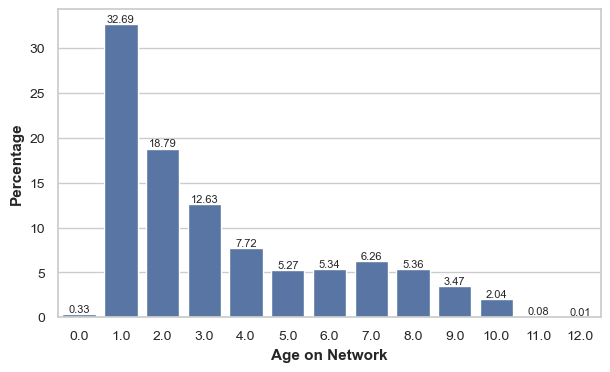

In [57]:
plt.figure(figsize = [7,4])
barplotresult = sns.barplot(x=telecom_df['aon_years'].value_counts().index, 
                                y=telecom_df['aon_years'].value_counts(normalize=True).mul(100).round(2))
plt.xlabel('Age on Network',fontweight='bold',fontsize=11)
plt.ylabel('Percentage',fontweight='bold',fontsize=11)
for i in barplotresult.containers:
        barplotresult.bar_label(i,fontsize=8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

1.4.2 Distribution of Customer churn

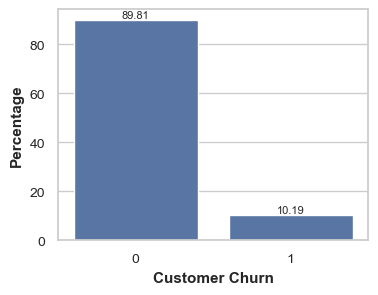

In [58]:
plt.figure(figsize = [4,3])
#sns.countplot(x = 'churn_probability', data = telecom_df)
barplotresult = sns.barplot( x=telecom_df['churn_probability'].value_counts().index, 
                                y=telecom_df['churn_probability'].value_counts(normalize=True).mul(100).round(2))

plt.xlabel('Customer Churn',fontweight='bold',fontsize=11)
plt.ylabel('Percentage',fontweight='bold',fontsize=11)
for i in barplotresult.containers:
        barplotresult.bar_label(i,fontsize=8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

#### <font color='black' size=3.2>1.5 Bivariate Analysis</font>

In [59]:
def draw_boxplot(df,target_var,continuous,varName):
    plt.figure(figsize = [12,4])
    
    Q1 = df[continuous].quantile(0.25)
    Q3 = df[continuous].quantile(0.75)
    IQR = Q3 - Q1
    Min_value = (Q1 - 1.5 * IQR)
    Max_value = (Q3 + 1.5 * IQR)
    print("Min value before which outlier exist: {}".format(Min_value))
    print("Max value after which outlier exist: {}".format(Max_value))

    plt.subplots_adjust(top = 0.90, bottom=0.01, hspace=0.3, wspace=0.3)
    plt.subplot(1,2,1)
    pltname = f" {varName} - With Outliers"
    plt.title(pltname,fontweight='bold',fontsize=11)
    sns.boxplot(data=df, x=target_var, y=df[continuous], color='#E67E22')
    plt.xlabel('Churn',fontweight='bold',fontsize=11)
    plt.ylabel(varName,fontweight='bold',fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.subplot(1,2,2)
    pltname = f" {varName} - Without Outliers"
    plt.title(pltname,fontweight='bold',fontsize=11)
    sns.boxplot(data=df, x=target_var, y=df[(df[continuous] <= Max_value) & (df[continuous] >= Min_value) ][continuous], color='#AF7AC5')
    plt.xlabel('Churn',fontweight='bold',fontsize=11)
    plt.ylabel(varName,fontweight='bold',fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    

    plt.tight_layout(pad = 4)
    plt.show()

1.5.1 Average Revenue per user

Min value before which outlier exist: -322.2339999999999
Max value after which outlier exist: 786.606


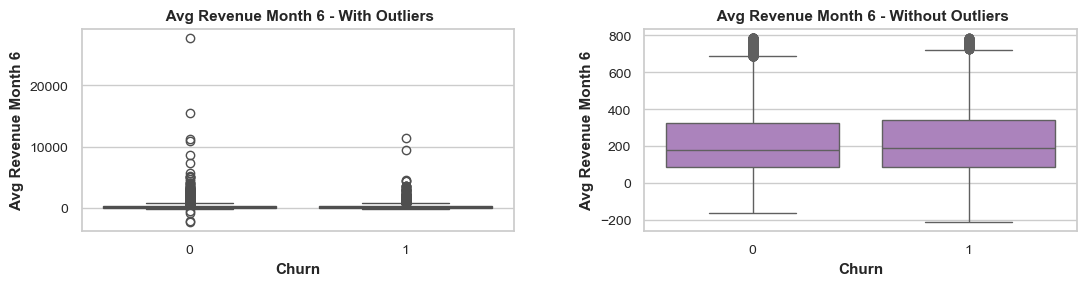

In [60]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='arpu_6', varName='Avg Revenue Month 6')

Min value before which outlier exist: -331.26925
Max value after which outlier exist: 783.35275


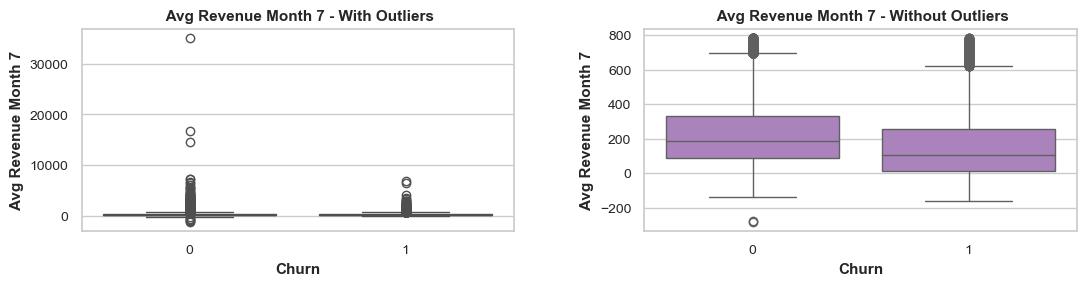

In [61]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='arpu_7', varName='Avg Revenue Month 7')

Min value before which outlier exist: -344.626
Max value after which outlier exist: 798.6299999999999


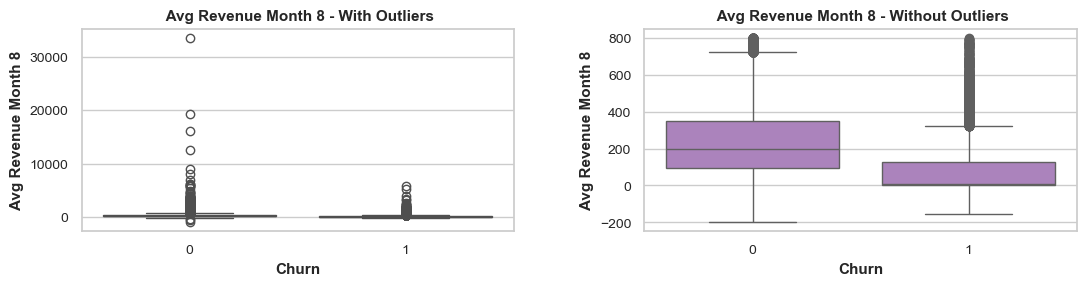

In [62]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='arpu_8', varName='Avg Revenue Month 8')

1.5.2 AON Years

Min value before which outlier exist: -5.0
Max value after which outlier exist: 11.0


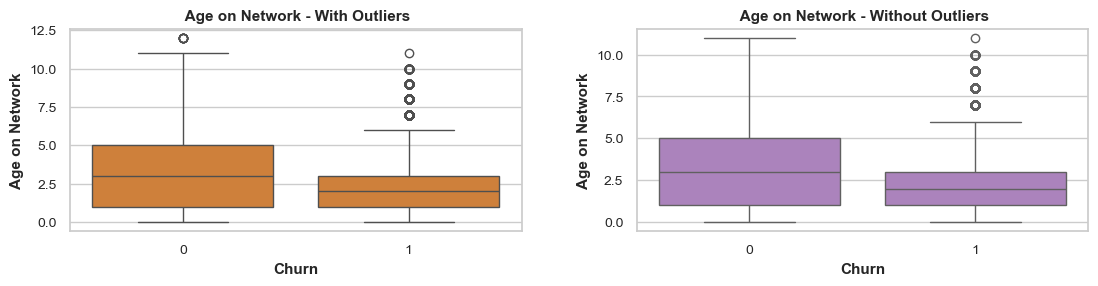

In [63]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='aon_years', varName='Age on Network')

1.5.3 Total Recharge Amount - Calls + Data

Min value before which outlier exist: -550.0
Max value after which outlier exist: 1210.0


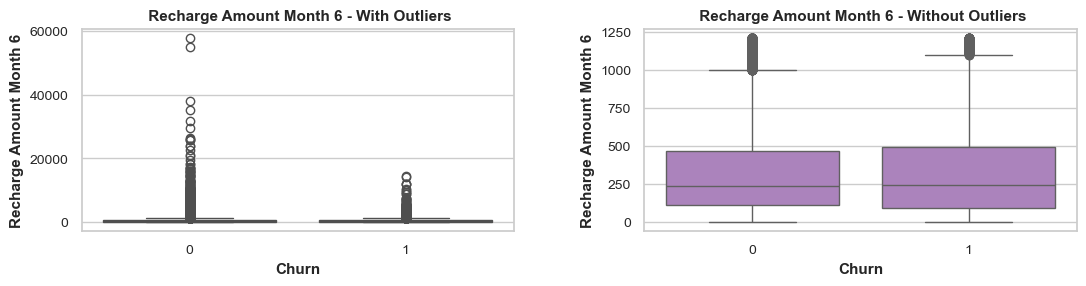

In [64]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='total_rech_amt_6_combined', varName='Recharge Amount Month 6')

Min value before which outlier exist: -550.0
Max value after which outlier exist: 1210.0


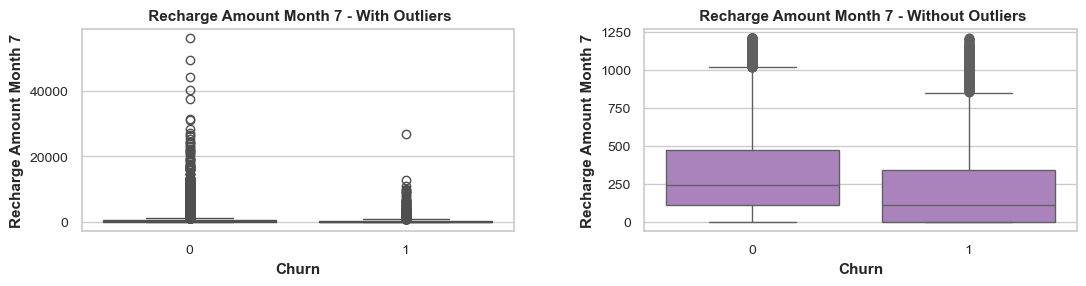

In [65]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='total_rech_amt_7_combined', varName='Recharge Amount Month 7')

Min value before which outlier exist: -587.0
Max value after which outlier exist: 1245.0


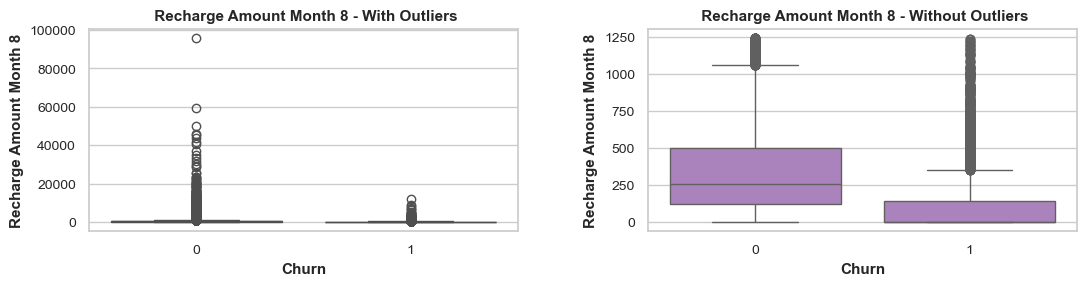

In [66]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='total_rech_amt_8_combined', varName='Recharge Amount Month 8')

1.5.4 Total Recharge Amount - Last Day recharge amount

Min value before which outlier exist: -165.0
Max value after which outlier exist: 275.0


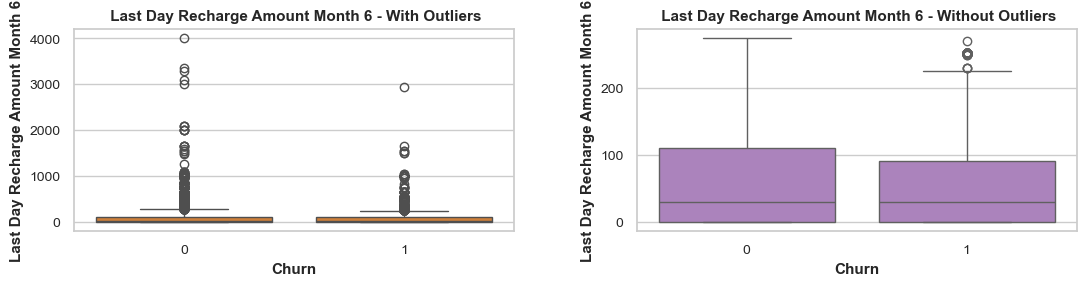

In [67]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='last_day_rch_amt_6', varName='Last Day Recharge Amount Month 6')

Min value before which outlier exist: -165.0
Max value after which outlier exist: 275.0


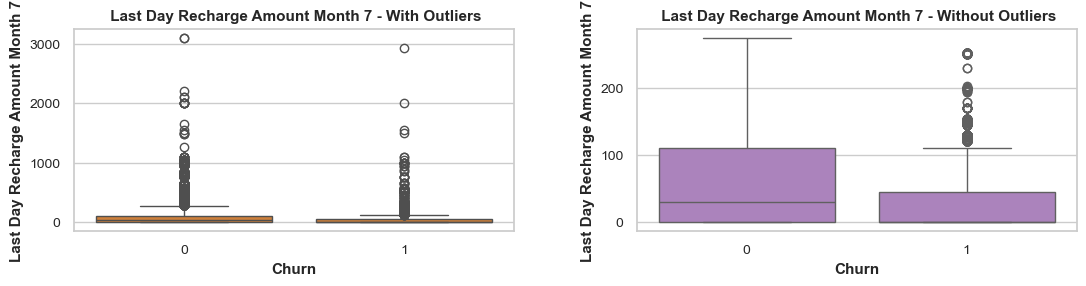

In [68]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='last_day_rch_amt_7', varName='Last Day Recharge Amount Month 7')

Min value before which outlier exist: -195.0
Max value after which outlier exist: 325.0


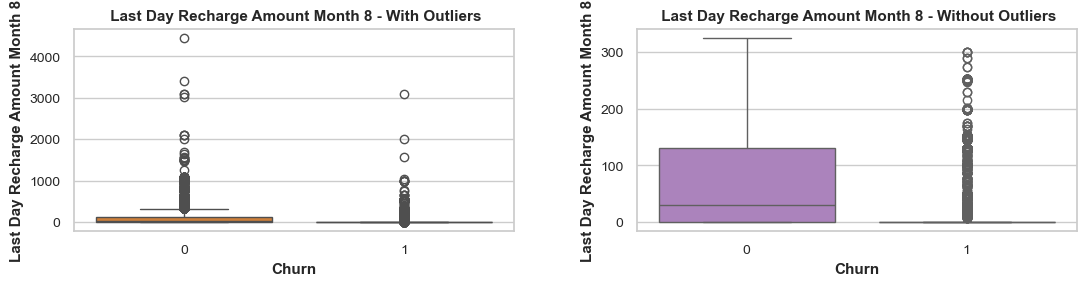

In [69]:
draw_boxplot(df=telecom_df,target_var='churn_probability',continuous='last_day_rch_amt_8', varName='Last Day Recharge Amount Month 8')

#### <font color='black' size=3.2>1.6 Outlier Analysis</font>

We shall check outliers for the set of related variables and see the pattern

In [70]:
def outliers_draw_boxplot(df,outlier_cols):
   plt.figure(figsize=(15, 10))
   plt.subplots_adjust(top = 0.90, bottom=0.01, hspace=0.3, wspace=0.3)
   chartNum =0 ;
   for i in outlier_cols:
        continuous=i
        Min_value = df[i].quantile(0.01)
        Max_value = df[i].quantile(0.99)

        OutlierCount  = len(df[(df[continuous] > Max_value) | (df[continuous] < Min_value) ][continuous])
        print("Variable ",continuous," - LowerBound:",Min_value,", UpperBound:",Max_value,", Outlier Count: ",OutlierCount)
        chartNum = chartNum+1
        plt.subplot(3,2,chartNum)
        g=sns.boxplot(data=df, y=df[continuous], color='#E67E22')
        plt.title(i, fontsize=12)
        g.tick_params(labelsize=10)
        plt.xlabel("")
        plt.ylabel("")

        chartNum = chartNum+1
        plt.subplot(3,2,chartNum)
        g=sns.boxplot(data=df, y=df[(df[continuous] <= Max_value) & (df[continuous] >= Min_value) ][continuous], color='#AF7AC5')
        plt.title(i, fontsize=12)
        g.tick_params(labelsize=10)
        plt.xlabel("")
        plt.ylabel("")
       
   plt.show()


1.6.1 Local Outgoing calls to another operator

Variable  loc_og_t2t_mou_6  - LowerBound: 0.0 , UpperBound: 535.0694000000019 , Outlier Count:  700
Variable  loc_og_t2t_mou_7  - LowerBound: 0.0 , UpperBound: 518.1930000000007 , Outlier Count:  700
Variable  loc_og_t2t_mou_8  - LowerBound: 0.0 , UpperBound: 506.6840000000008 , Outlier Count:  700


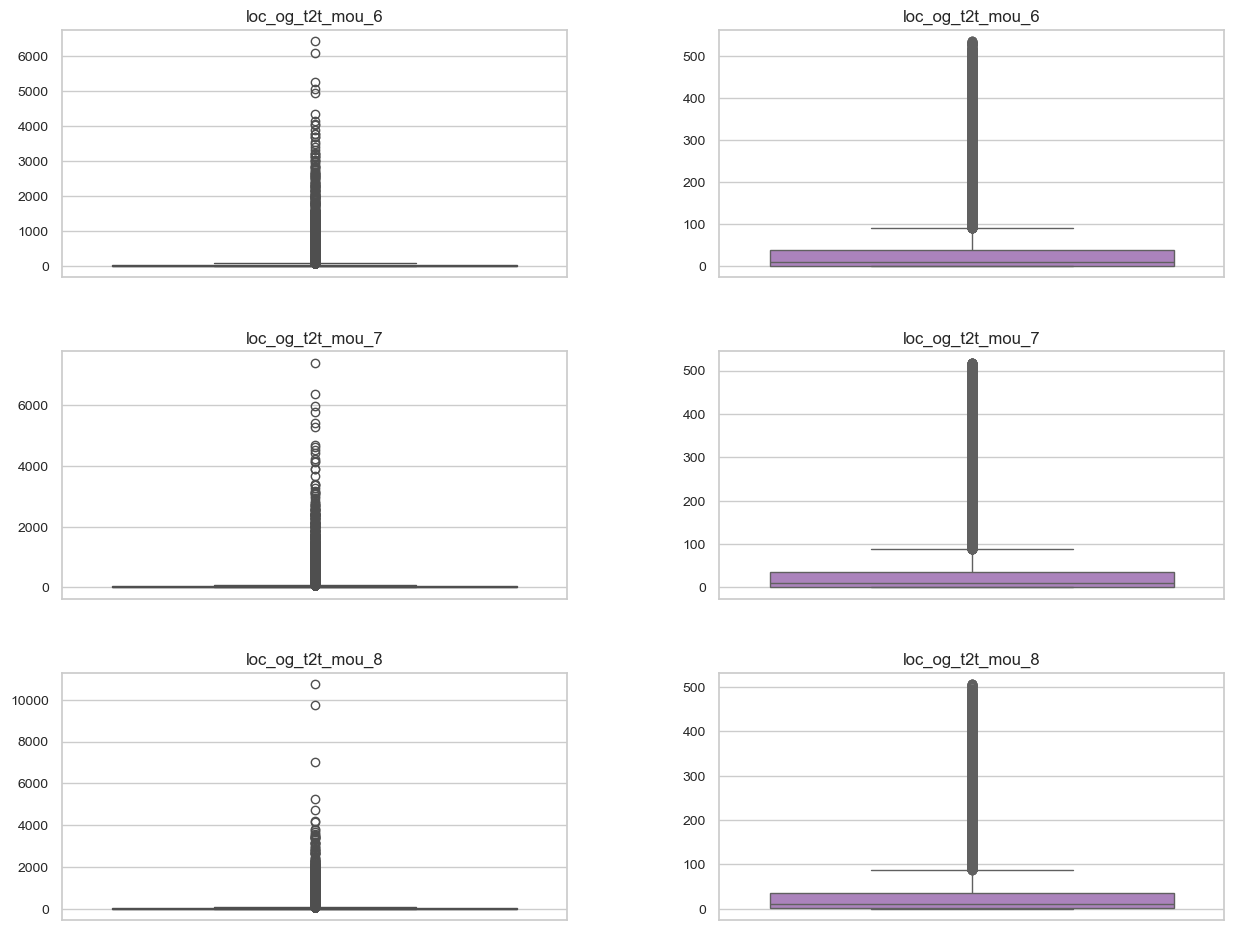

In [71]:
loc_og_t2t =  ['loc_og_t2t_mou_6','loc_og_t2t_mou_7','loc_og_t2t_mou_8']
outliers_draw_boxplot(df=telecom_df,outlier_cols=loc_og_t2t)

As we could see we have wide range of outliers which can be treated by capping Max value to 99% quantile and Min value to 1% quantile

In [72]:
def find_outliers(df):
    col_list = list(telecom_df.columns)
    col_list.remove('churn_probability')
    outlier_df=pd.DataFrame()
    
    for col in col_list:
        lowerBound = df[col].quantile(0.01)
        upperBound = df[col].quantile(0.99)

        OutlierCount  = len(df[(df[col] > upperBound) | (df[col] < lowerBound) ][col])
        if OutlierCount>0 :
           # print("Variable ",col," - LowerBound:",lowerBound,", UpperBound:",upperBound,", OutlierCount: ",OutlierCount)
            new_row = {"Variable": col, "LowerBound": lowerBound, "UpperBound":upperBound, "OutlierCount":OutlierCount}
            outlier_df = pd.concat([outlier_df, pd.DataFrame([new_row])], ignore_index=True)
    return outlier_df

In [73]:
outlier_df = find_outliers (telecom_df)

In [74]:
outlier_df

,Variable,LowerBound,UpperBound,OutlierCount
0,arpu_6,0.0,1400.276640,992
1,arpu_7,0.0,1414.891380,1041
2,arpu_8,0.0,1445.054800,1052
3,onnet_mou_6,0.0,1429.040400,700
4,onnet_mou_7,0.0,1461.342200,700
...,...,...,...,...
153,total_rech_amt_6_combined,0.0,3564.060000,700
154,total_rech_amt_7_combined,0.0,3801.020000,700
155,total_rech_amt_8_combined,0.0,3848.020000,700
156,av_rech_amt_3months,20.0,3384.673333,1377


NOTE: 158 rows is having outliers which will be treated by capping

In [75]:
def remove_outliers(df):
    col_list = list(telecom_df.columns)
    col_list.remove('churn_probability')

    # Applying outlier capping for all applicable columns
    for col in col_list:
        lowerBound = df[col].quantile(0.01)
        upperBound = df[col].quantile(0.99)
        df[col] = np.clip(df[col], lowerBound, upperBound)

In [76]:
telecom_df['arpu_6'].describe()

count    69999.000000
mean       283.134365
std        334.213918
min      -2258.709000
25%         93.581000
50%        197.484000
75%        370.791000
max      27731.088000
Name: arpu_6, dtype: float64

In [77]:
remove_outliers(telecom_df)

In [78]:
telecom_df['arpu_6'].describe()

count    69999.000000
mean       276.926861
std        268.478830
min          0.000000
25%         93.581000
50%        197.484000
75%        370.791000
max       1400.276640
Name: arpu_6, dtype: float64

In [79]:
telecom_df.shape

(69999, 168)

#### <font color='black' size=3.2>1.7 MultiVariate Analysis</font>

Creating correlation matrix and heatmap to understand the relationship b/w features. Since plotting 169 variables will not give any inference, we shall take only top 20 variables that are highly correlated to target variable

In [80]:
corr = telecom_df.corr().abs()
corr = corr[corr>=.85]
corr_result = corr.unstack().sort_values(ascending=False).drop_duplicates()
corr_result

arpu_6                 arpu_6                       1.000000
sachet_2g_7            count_rech_2g_7              0.976841
sachet_2g_8            count_rech_2g_8              0.975772
sachet_2g_6            count_rech_2g_6              0.972513
arpu_8                 total_rech_amt_8             0.950827
arpu_3g_7              arpu_2g_7                    0.950727
arpu_6                 total_rech_amt_6             0.950457
arpu_7                 total_rech_amt_7             0.949949
arpu_2g_6              arpu_3g_6                    0.947419
arpu_3g_8              arpu_2g_8                    0.945300
total_rech_data_7      count_rech_2g_7              0.928730
count_rech_2g_8        total_rech_data_8            0.926632
total_rech_data_6      count_rech_2g_6              0.924029
loc_ic_mou_6           total_ic_mou_6               0.913620
total_rech_data_7      sachet_2g_7                  0.910834
total_rech_data_8      sachet_2g_8                  0.909941
loc_ic_mou_8           t

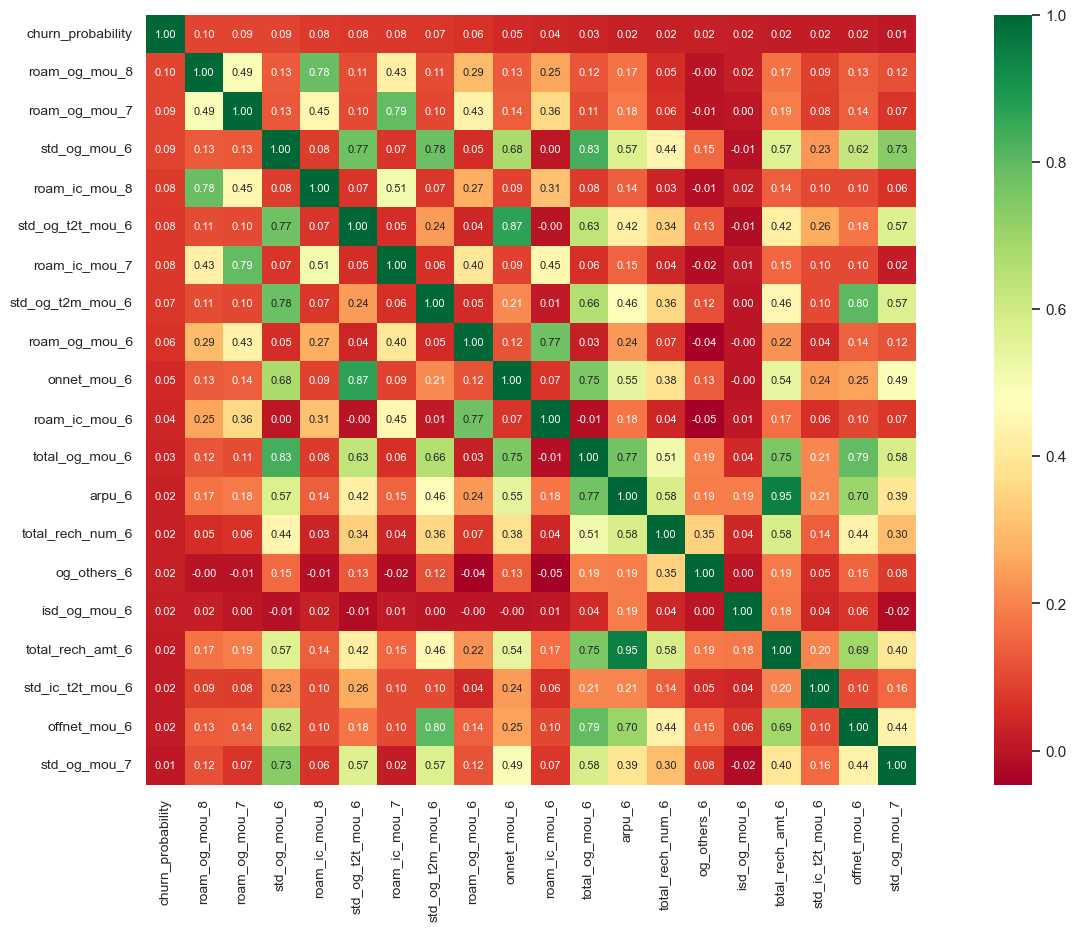

In [81]:
corr = telecom_df.corr()

plt.figure(figsize=[20,10])

k = 20 # number of variables for the heatmap
cols = corr.nlargest(k,'churn_probability')['churn_probability'].index
corrmatrix = np.corrcoef(telecom_df[cols].values.T)
sns.set(font_scale=1)
ax = sns.heatmap(corrmatrix, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size':8},
                yticklabels=cols.values, xticklabels=cols.values, cmap='RdYlGn')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
plt.show()

As we could see, there are many variables which are highly correlated to each other which needs to be handled during modelling

<font color='#006400' size=4.8><span style="text-decoration:underline">***Observations:***</span></br></font>
</br>
<font size=3.5> - Only recent customers has stayed back in the network </font>
</br>
<font size=3.5> - We could see huge imbalance on distribution of target variable (90-10) which needs to be handled before modelling</font>
</br>
<font size=3.5> - Outlier Treatment via capping - for around 158 variables</font>
</br>
<font size=3.5> - Many variables are highly correlated which needs to be handled</font>
</br>
<font size=3.5> - Shape of Data before Train-Test split: (69999, 168) </font>
</br>

#### <font color='#000080' size=5>***2. Data Preparation:***</font>

#### <font color='black' size=3.2>2.1 Train Test Split</font>

In [82]:
X = telecom_df.drop(['churn_probability'], axis=1)
y = telecom_df['churn_probability']

In [83]:
X.head(5)

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,day_of_last_rech_7,day_of_last_rech_8,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_rech_amt_6_combined,total_rech_amt_7_combined,total_rech_amt_8_combined,av_rech_amt_3months,aon_years
0,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,...,10,24,0.0,0.0,0.0,77.0,65.0,10.0,50.666667,5.0
1,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,...,10,26,0.0,145.0,0.0,0.0,290.0,50.0,113.333333,2.0
2,60.806,103.176,0.000,0.53,15.93,0.00,53.99,82.05,0.00,0.00,...,22,24,0.0,0.0,0.0,70.0,120.0,0.0,63.333333,2.0
3,156.362,205.260,111.095,7.26,16.01,0.00,68.76,78.48,50.23,0.00,...,21,25,0.0,0.0,0.0,160.0,240.0,130.0,176.666667,3.0
4,240.708,128.191,101.565,21.28,4.83,6.13,56.99,38.11,9.63,53.64,...,26,30,1225.0,1337.0,852.0,1515.0,1473.0,974.0,1320.666667,2.0


In [84]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: churn_probability, dtype: int64

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [86]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(48999, 167) (21000, 167) (48999,) (21000,)


#### <font color='black' size=3.2>2.2 Feature Scaling - Min Max Scaler</font>

In [87]:
# Instantiate an object of MinMaxScaler
scaler = MinMaxScaler()

Remove Boolean columns

In [88]:
cols_to_scale = list(X_train.columns)
cols_to_scale.remove('night_pck_user_6')
cols_to_scale.remove('night_pck_user_7')
cols_to_scale.remove('night_pck_user_8')
cols_to_scale.remove('fb_user_6')
cols_to_scale.remove('fb_user_7')
cols_to_scale.remove('fb_user_8')

In [89]:
# Perform fit and transform on the X_train dataset
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

In [90]:
# Perform only transform on the X_test dataset
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [91]:
X_train.describe()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,day_of_last_rech_7,day_of_last_rech_8,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_rech_amt_6_combined,total_rech_amt_7_combined,total_rech_amt_8_combined,av_rech_amt_3months,aon_years
count,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,...,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000,48999.000000
mean,0.197069,0.192131,0.188357,0.083751,0.082468,0.081272,0.120823,0.120359,0.119905,0.034064,...,0.808191,0.791801,0.046325,0.046455,0.047222,0.125283,0.120787,0.119499,0.131346,0.263316
std,0.191148,0.190149,0.189917,0.164845,0.166075,0.164586,0.173559,0.175705,0.175321,0.137003,...,0.213584,0.245432,0.147398,0.147385,0.147420,0.162350,0.164028,0.162881,0.162287,0.289186
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.066403,0.061265,0.057888,0.003751,0.003350,0.002885,0.018740,0.017452,0.015835,0.000000,...,0.709677,0.774194,0.000000,0.000000,0.000000,0.030864,0.028940,0.025987,0.034971,0.000000
50%,0.140563,0.135487,0.132998,0.021490,0.019852,0.019277,0.058567,0.056093,0.055380,0.000000,...,0.870968,0.870968,0.000000,0.000000,0.000000,0.074634,0.068140,0.067567,0.077868,0.111111
75%,0.264936,0.258345,0.256846,0.079186,0.074315,0.073328,0.146046,0.143856,0.145279,0.000000,...,0.967742,0.967742,0.005352,0.005620,0.007773,0.153757,0.144698,0.145010,0.160293,0.444444
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### <font color='black' size=3.2>2.3 Handling Class Imbalance - SMOTE </font>

In [92]:
smote = SMOTE(random_state = 1) 

In [93]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [94]:
print("Target Variable distribution before SMOTE: ", y_train.shape)
print("Target Variable distribution after SMOTE: ", y_train_smote.shape)

Target Variable distribution before SMOTE:  (48999,)
Target Variable distribution after SMOTE:  (87932,)


In [95]:
len(y_train_smote.values)

87932

In [96]:
### Check the Churn Rate
churn_rate = (sum(y_train_smote.values)/len(y_train_smote.values))*100
churn_rate

50.0

NOTE: Class Imabalancing is handled only on the Training set allowing the model to read the data well and can see the performance of model on unseen data - Test Dataset

<font color='#006400' size=4.8><span style="text-decoration:underline">***Observations:***</span></br></font>
</br>
<font size=3.5> - Train Data Size: (48999, 167), Test Data Size: (21000, 167)  </font>
</br>
<font size=3.5> - Used Min Max scalar for standardization of Numeric variables  </font>
</br>
<font size=3.5> - SMOTE is used to handle class imbalance (Only on Training Dataset) </font>
</br>

#### <font color='#000080' size=5>***3. Model Building:***</font>

In [97]:
model_training_stats_df = pd.DataFrame()
model_test_stats_df = pd.DataFrame()

In [212]:
model_training_stats_df = pd.DataFrame()

#### <font color='black' size=3.2>3.0 Create Reusable functions </font>

In [98]:
def calculate_vifs(X):
    vif = pd.DataFrame()
    vif['Features']= X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by='VIF', ascending=False)
    return vif

In [99]:
def plot_roc_curve(y,y_pred):
    fpr, tpr, thresholds = roc_curve(y_true= y,y_score = y_pred) 
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Telecom churn Classification')
    plt.legend()
    plt.show()
    return round(roc_auc,2)

In [100]:
def predict_model_performance(model, X):
    y = model.predict(X)
    return y

In [101]:
def evaluate_model_perf(y_pred,y):
    accuracy_score = round( metrics.accuracy_score(y_true=y, y_pred=y_pred),2)
    confusion_matrix = metrics.confusion_matrix(y_true=y, y_pred=y_pred)
    precision_score = round(metrics.precision_score(y_true=y, y_pred=y_pred),2)
    recall_score = round(metrics.recall_score(y_true=y, y_pred=y_pred),2)

    print("Accuracy score:", accuracy_score)
    print("Confusion matrix:\n",confusion_matrix)
    print("Precision score:",precision_score)
    print("Recall score:",recall_score)
    
    return accuracy_score, confusion_matrix, precision_score, recall_score

In [102]:
def print_evaluation_metrics(accuracy_score, confusion_matrix, precision_score, recall_score, accuracy_score_test,confusion_matrix_test,precision_score_test,recall_score_test):
    #Print the metrics
    print("")
    result = [['Accuracy', accuracy_score, accuracy_score_test], 
          ['TN %', confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1]),
                            confusion_matrix_test[0][0]/( confusion_matrix_test[0][0]+ confusion_matrix_test[0][1])], 
          ['FP %', confusion_matrix[0][1]/(confusion_matrix[0][0]+confusion_matrix[0][1]),
                          confusion_matrix_test[0][1]/(confusion_matrix_test[0][0]+confusion_matrix_test[0][1])], 
          ['FN %', confusion_matrix[1][0]/(confusion_matrix[1][0]+confusion_matrix[1][1]),
                           confusion_matrix_test[1][0]/(confusion_matrix_test[1][0]+confusion_matrix_test[1][1])], 
          ['TP % ', confusion_matrix[1][1]/(confusion_matrix[1][0]+confusion_matrix[1][1]),
                           confusion_matrix_test[1][1]/(confusion_matrix_test[1][0]+confusion_matrix_test[1][1])],
          ['Precision', precision_score, precision_score_test],
          ['Recall', recall_score, recall_score_test]
        ]
    result_df = pd.DataFrame(result, columns=['Metric', 'Train Data', 'Test Data'])
    print(result_df)

#### <font color='black' size=3.2>3.1 Model1: Logistic Regression - Interpretable Model without PCA </font>

We shall create a Interpretable Model using Logistic regression without PCA to identify the strong predictors of churn which the company can use as in input to reduce the churn rate

##### 3.1.1 Feature Selection Using RFE

In [103]:
logreg = LogisticRegression(random_state=15)

In [104]:
#Select top 20 features
rfe = RFE(logreg, n_features_to_select =20)
rfe = rfe.fit(X_train_smote, y_train_smote)

In [105]:
#Get the list of features selected by RFE
list(zip(X_train_smote.columns, rfe.support_, rfe.ranking_))

[('arpu_6', False, 12),
 ('arpu_7', True, 1),
 ('arpu_8', False, 8),
 ('onnet_mou_6', False, 126),
 ('onnet_mou_7', False, 6),
 ('onnet_mou_8', False, 20),
 ('offnet_mou_6', False, 68),
 ('offnet_mou_7', False, 51),
 ('offnet_mou_8', True, 1),
 ('roam_ic_mou_6', False, 81),
 ('roam_ic_mou_7', False, 32),
 ('roam_ic_mou_8', False, 117),
 ('roam_og_mou_6', False, 69),
 ('roam_og_mou_7', False, 118),
 ('roam_og_mou_8', True, 1),
 ('loc_og_t2t_mou_6', False, 104),
 ('loc_og_t2t_mou_7', False, 134),
 ('loc_og_t2t_mou_8', True, 1),
 ('loc_og_t2m_mou_6', False, 13),
 ('loc_og_t2m_mou_7', False, 88),
 ('loc_og_t2m_mou_8', False, 22),
 ('loc_og_t2f_mou_6', False, 28),
 ('loc_og_t2f_mou_7', False, 106),
 ('loc_og_t2f_mou_8', False, 46),
 ('loc_og_t2c_mou_6', False, 38),
 ('loc_og_t2c_mou_7', False, 119),
 ('loc_og_t2c_mou_8', False, 25),
 ('loc_og_mou_6', False, 57),
 ('loc_og_mou_7', False, 87),
 ('loc_og_mou_8', False, 21),
 ('std_og_t2t_mou_6', False, 48),
 ('std_og_t2t_mou_7', False, 7),
 ('

In [106]:
#columns selected by RFE
rfe_col = X_train_smote.columns[ rfe.support_ ]

In [107]:
rfe_col

Index(['arpu_7', 'offnet_mou_8', 'roam_og_mou_8', 'loc_og_t2t_mou_8',
       'std_og_t2t_mou_8', 'std_og_t2m_mou_8', 'std_og_mou_8',
       'loc_ic_t2t_mou_8', 'loc_ic_t2m_mou_8', 'loc_ic_t2f_mou_8',
       'std_ic_t2f_mou_8', 'std_ic_mou_8', 'total_ic_mou_8', 'spl_ic_mou_8',
       'total_rech_num_8', 'last_day_rch_amt_8', 'count_rech_2g_7',
       'av_rech_amt_data_8', 'arpu_3g_8', 'sachet_2g_7'],
      dtype='object')

In [108]:
len(rfe_col)

20

##### 3.1.2 Build Logistic Regression Model with above 20 features in the dataset

In [109]:
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])

In [110]:
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())

In [111]:
%%time
res = model1.fit()

CPU times: total: 1.12 s
Wall time: 428 ms


In [112]:
# Checking the summary of model statistics
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87911
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -35982.
Date:                Wed, 15 May 2024   Deviance:                       71965.
Time:                        10:24:00   Pearson chi2:                 4.74e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4333
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6448      0.016    103.585      0.000       1.614       1.676
arpu_7                 2.8585      0.082     35.028      0.000       2.699       3.018
offnet_mou_8          -6.7484      0.320    -21.108      0.000      -7.375      -6.122
roam_og_mou_8          2.7020      0.081     33.287      0.000       2.543       2.861
loc_og_t2t_mou_8      -2.9420      0.198    -14.821      0.000      -3.331      -2.553
std_og_t2t_mou_8      -3.4842      0.342    -10.183      0.000      -4.155      -2.814
std_og_t2m_mou_8       2.8970      0.396      7.320      0.000       2.121       3.673
std_og_mou_8           3.7020      0.467      7.926      0.000       2.787       4.617
loc_ic_t2t_mou_8      -4.7061      0.202    -23.271      0.000      -5.102      -4.310
loc_ic_t2m_mou_8     -10.5517      0.247    -42.742      0.000     -11.036     -10.068
loc_ic_t2f_mou_8      -4.8791      0.213    -22.945      0.000      -5.296      -4.462
std_ic_t2f_mou_8      -2.2061      0.166    -13.290      0.000      -2.531      -1.881
std_ic_mou_8          -3.3720      0.153    -22.020      0.000      -3.672      -3.072
total_ic_mou_8         4.1874      0.254     16.480      0.000       3.689       4.685
spl_ic_mou_8          -5.2649      0.153    -34.484      0.000      -5.564      -4.966
total_rech_num_8      -3.9575      0.099    -40.110      0.000      -4.151      -3.764
last_day_rch_amt_8    -3.6066      0.082    -43.800      0.000      -3.768      -3.445
count_rech_2g_7       -5.5996      0.417    -13.418      0.000      -6.418      -4.782
av_rech_amt_data_8    -3.8655      0.143    -27.109      0.000      -4.145      -3.586
arpu_3g_8              2.6872      0.157     17.151      0.000       2.380       2.994
sachet_2g_7            5.3334      0.418     12.768      0.000       4.515       6.152
======================================================================================
"""

P-value for all the features is 0. Lets check VIF

In [113]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
7,std_og_mou_8,48.35
17,count_rech_2g_7,28.62
20,sachet_2g_7,27.12
6,std_og_t2m_mou_8,23.20
5,std_og_t2t_mou_8,20.29
13,total_ic_mou_8,11.28
2,offnet_mou_8,7.06
9,loc_ic_t2m_mou_8,5.60
18,av_rech_amt_data_8,3.55
8,loc_ic_t2t_mou_8,3.14


VIF is too high for std_og_mou_8. Remove this feature and check

In [114]:
rfe_col = rfe_col.drop('std_og_mou_8', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87912
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36012.
Date:                Wed, 15 May 2024   Deviance:                       72024.
Time:                        10:24:03   Pearson chi2:                 4.92e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4329
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6378      0.016    103.414      0.000       1.607       1.669
arpu_7                 2.8891      0.082     35.337      0.000       2.729       3.049
offnet_mou_8          -6.4219      0.314    -20.455      0.000      -7.037      -5.807
roam_og_mou_8          2.6582      0.081     32.894      0.000       2.500       2.817
loc_og_t2t_mou_8      -2.9992      0.200    -14.992      0.000      -3.391      -2.607
std_og_t2t_mou_8      -0.8736      0.085    -10.226      0.000      -1.041      -0.706
std_og_t2m_mou_8       5.1554      0.274     18.795      0.000       4.618       5.693
loc_ic_t2t_mou_8      -4.6934      0.202    -23.182      0.000      -5.090      -4.297
loc_ic_t2m_mou_8     -10.6561      0.247    -43.135      0.000     -11.140     -10.172
loc_ic_t2f_mou_8      -4.8839      0.213    -22.933      0.000      -5.301      -4.467
std_ic_t2f_mou_8      -2.1701      0.166    -13.074      0.000      -2.495      -1.845
std_ic_mou_8          -3.4144      0.153    -22.278      0.000      -3.715      -3.114
total_ic_mou_8         4.1934      0.254     16.483      0.000       3.695       4.692
spl_ic_mou_8          -5.2762      0.153    -34.565      0.000      -5.575      -4.977
total_rech_num_8      -3.9708      0.099    -40.255      0.000      -4.164      -3.777
last_day_rch_amt_8    -3.6176      0.082    -43.924      0.000      -3.779      -3.456
count_rech_2g_7       -5.6180      0.417    -13.457      0.000      -6.436      -4.800
av_rech_amt_data_8    -3.8591      0.143    -27.066      0.000      -4.139      -3.580
arpu_3g_8              2.6828      0.157     17.117      0.000       2.376       2.990
sachet_2g_7            5.3581      0.418     12.823      0.000       4.539       6.177
======================================================================================
"""

In [115]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
16,count_rech_2g_7,28.62
19,sachet_2g_7,27.12
12,total_ic_mou_8,11.28
2,offnet_mou_8,7.04
8,loc_ic_t2m_mou_8,5.60
6,std_og_t2m_mou_8,5.25
17,av_rech_amt_data_8,3.55
7,loc_ic_t2t_mou_8,3.14
18,arpu_3g_8,3.08
0,const,2.59


VIF is too high for count_rech_2g_7. Remove this feature and check

In [116]:
rfe_col = rfe_col.drop('count_rech_2g_7', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87913
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36105.
Date:                Wed, 15 May 2024   Deviance:                       72209.
Time:                        10:24:06   Pearson chi2:                 4.51e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4317
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6272      0.016    103.061      0.000       1.596       1.658
arpu_7                 2.7173      0.080     33.972      0.000       2.561       2.874
offnet_mou_8          -6.3415      0.313    -20.269      0.000      -6.955      -5.728
roam_og_mou_8          2.6809      0.081     33.216      0.000       2.523       2.839
loc_og_t2t_mou_8      -2.9723      0.200    -14.879      0.000      -3.364      -2.581
std_og_t2t_mou_8      -0.8080      0.085     -9.504      0.000      -0.975      -0.641
std_og_t2m_mou_8       5.1425      0.274     18.803      0.000       4.606       5.679
loc_ic_t2t_mou_8      -4.6475      0.202    -22.997      0.000      -5.044      -4.251
loc_ic_t2m_mou_8     -10.6802      0.247    -43.178      0.000     -11.165     -10.195
loc_ic_t2f_mou_8      -4.9411      0.214    -23.064      0.000      -5.361      -4.521
std_ic_t2f_mou_8      -2.1586      0.166    -13.000      0.000      -2.484      -1.833
std_ic_mou_8          -3.3759      0.153    -22.053      0.000      -3.676      -3.076
total_ic_mou_8         4.1227      0.254     16.214      0.000       3.624       4.621
spl_ic_mou_8          -5.2963      0.153    -34.636      0.000      -5.596      -4.997
total_rech_num_8      -3.9111      0.098    -39.739      0.000      -4.104      -3.718
last_day_rch_amt_8    -3.6124      0.082    -43.912      0.000      -3.774      -3.451
av_rech_amt_data_8    -4.4536      0.137    -32.520      0.000      -4.722      -4.185
arpu_3g_8              3.2053      0.152     21.085      0.000       2.907       3.503
sachet_2g_7           -0.1443      0.083     -1.737      0.082      -0.307       0.019
======================================================================================
"""

In [117]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
12,total_ic_mou_8,11.28
2,offnet_mou_8,7.04
8,loc_ic_t2m_mou_8,5.60
6,std_og_t2m_mou_8,5.25
7,loc_ic_t2t_mou_8,3.14
16,av_rech_amt_data_8,3.09
17,arpu_3g_8,2.84
0,const,2.59
11,std_ic_mou_8,2.37
14,total_rech_num_8,1.81


sachet_2g_7 is having high p-value (>0.05). Remove this feature

In [118]:
rfe_col = rfe_col.drop('sachet_2g_7', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87914
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36106.
Date:                Wed, 15 May 2024   Deviance:                       72212.
Time:                        10:24:08   Pearson chi2:                 4.55e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4317
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6268      0.016    103.052      0.000       1.596       1.658
arpu_7                 2.7024      0.079     34.000      0.000       2.547       2.858
offnet_mou_8          -6.3217      0.313    -20.224      0.000      -6.934      -5.709
roam_og_mou_8          2.6859      0.081     33.303      0.000       2.528       2.844
loc_og_t2t_mou_8      -2.9674      0.200    -14.863      0.000      -3.359      -2.576
std_og_t2t_mou_8      -0.7942      0.085     -9.386      0.000      -0.960      -0.628
std_og_t2m_mou_8       5.1393      0.273     18.793      0.000       4.603       5.675
loc_ic_t2t_mou_8      -4.6484      0.202    -23.002      0.000      -5.044      -4.252
loc_ic_t2m_mou_8     -10.6808      0.247    -43.187      0.000     -11.166     -10.196
loc_ic_t2f_mou_8      -4.9408      0.214    -23.065      0.000      -5.361      -4.521
std_ic_t2f_mou_8      -2.1567      0.166    -12.991      0.000      -2.482      -1.831
std_ic_mou_8          -3.3741      0.153    -22.045      0.000      -3.674      -3.074
total_ic_mou_8         4.1243      0.254     16.228      0.000       3.626       4.622
spl_ic_mou_8          -5.2963      0.153    -34.628      0.000      -5.596      -4.997
total_rech_num_8      -3.9367      0.097    -40.433      0.000      -4.128      -3.746
last_day_rch_amt_8    -3.6051      0.082    -43.887      0.000      -3.766      -3.444
av_rech_amt_data_8    -4.5146      0.133    -34.033      0.000      -4.775      -4.255
arpu_3g_8              3.2639      0.148     21.996      0.000       2.973       3.555
======================================================================================
"""

In [119]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
12,total_ic_mou_8,11.28
2,offnet_mou_8,7.03
8,loc_ic_t2m_mou_8,5.60
6,std_og_t2m_mou_8,5.25
7,loc_ic_t2t_mou_8,3.14
16,av_rech_amt_data_8,2.81
17,arpu_3g_8,2.68
0,const,2.59
11,std_ic_mou_8,2.37
1,arpu_7,1.74


VIF is too high for total_ic_mou_8. Remove this feature and check

In [120]:
rfe_col = rfe_col.drop('total_ic_mou_8', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87915
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36228.
Date:                Wed, 15 May 2024   Deviance:                       72457.
Time:                        10:24:11   Pearson chi2:                 6.68e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4301
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6212      0.016    102.874      0.000       1.590       1.652
arpu_7                 2.7107      0.079     34.103      0.000       2.555       2.866
offnet_mou_8          -6.2056      0.312    -19.890      0.000      -6.817      -5.594
roam_og_mou_8          2.6446      0.080     32.911      0.000       2.487       2.802
loc_og_t2t_mou_8      -3.1271      0.203    -15.371      0.000      -3.526      -2.728
std_og_t2t_mou_8      -0.8347      0.085     -9.876      0.000      -1.000      -0.669
std_og_t2m_mou_8       4.9989      0.273     18.322      0.000       4.464       5.534
loc_ic_t2t_mou_8      -2.7892      0.168    -16.577      0.000      -3.119      -2.459
loc_ic_t2m_mou_8      -8.4375      0.206    -40.907      0.000      -8.842      -8.033
loc_ic_t2f_mou_8      -4.4700      0.214    -20.880      0.000      -4.890      -4.050
std_ic_t2f_mou_8      -2.1751      0.166    -13.065      0.000      -2.501      -1.849
std_ic_mou_8          -1.7193      0.111    -15.512      0.000      -1.937      -1.502
spl_ic_mou_8          -5.2711      0.153    -34.500      0.000      -5.571      -4.972
total_rech_num_8      -3.9388      0.097    -40.524      0.000      -4.129      -3.748
last_day_rch_amt_8    -3.5821      0.082    -43.535      0.000      -3.743      -3.421
av_rech_amt_data_8    -4.4898      0.132    -33.928      0.000      -4.749      -4.230
arpu_3g_8              3.2607      0.148     22.014      0.000       2.970       3.551
======================================================================================
"""

In [121]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
2,offnet_mou_8,7.03
6,std_og_t2m_mou_8,5.25
15,av_rech_amt_data_8,2.81
16,arpu_3g_8,2.68
0,const,2.58
8,loc_ic_t2m_mou_8,1.98
1,arpu_7,1.74
13,total_rech_num_8,1.73
4,loc_og_t2t_mou_8,1.68
7,loc_ic_t2t_mou_8,1.62


VIF is high for offnet_mou_8. Remove this feature and check

In [122]:
rfe_col = rfe_col.drop('offnet_mou_8', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87916
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36461.
Date:                Wed, 15 May 2024   Deviance:                       72922.
Time:                        10:24:13   Pearson chi2:                 2.64e+07
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4271
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6582      0.016    105.765      0.000       1.627       1.689
arpu_7                 2.3412      0.076     30.948      0.000       2.193       2.489
roam_og_mou_8          1.9507      0.070     27.859      0.000       1.813       2.088
loc_og_t2t_mou_8      -4.1292      0.216    -19.111      0.000      -4.553      -3.706
std_og_t2t_mou_8      -0.5508      0.082     -6.682      0.000      -0.712      -0.389
std_og_t2m_mou_8      -0.1235      0.086     -1.440      0.150      -0.292       0.045
loc_ic_t2t_mou_8      -2.5602      0.167    -15.326      0.000      -2.888      -2.233
loc_ic_t2m_mou_8     -10.2446      0.193    -53.205      0.000     -10.622      -9.867
loc_ic_t2f_mou_8      -4.6443      0.216    -21.454      0.000      -5.069      -4.220
std_ic_t2f_mou_8      -2.2938      0.167    -13.699      0.000      -2.622      -1.966
std_ic_mou_8          -1.6413      0.110    -14.866      0.000      -1.858      -1.425
spl_ic_mou_8          -5.2683      0.153    -34.443      0.000      -5.568      -4.969
total_rech_num_8      -4.1345      0.096    -42.869      0.000      -4.324      -3.945
last_day_rch_amt_8    -3.8395      0.082    -47.072      0.000      -3.999      -3.680
av_rech_amt_data_8    -4.3719      0.132    -33.233      0.000      -4.630      -4.114
arpu_3g_8              3.2523      0.147     22.058      0.000       2.963       3.541
======================================================================================
"""

In [123]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
14,av_rech_amt_data_8,2.80
15,arpu_3g_8,2.68
0,const,2.53
12,total_rech_num_8,1.70
1,arpu_7,1.64
7,loc_ic_t2m_mou_8,1.62
6,loc_ic_t2t_mou_8,1.61
3,loc_og_t2t_mou_8,1.57
5,std_og_t2m_mou_8,1.41
13,last_day_rch_amt_8,1.33


std_og_t2m_mou_8 is having high p-value (>0.05). Remove this feature

In [124]:
rfe_col = rfe_col.drop('std_og_t2m_mou_8', 1)
X_train_model1 = sm.add_constant(X_train_smote[rfe_col])
model1 = sm.GLM(y_train_smote, X_train_model1, family = sm.families.Binomial())
res = model1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:                87932
Model:                            GLM   Df Residuals:                    87917
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36462.
Date:                Wed, 15 May 2024   Deviance:                       72924.
Time:                        10:24:14   Pearson chi2:                 2.63e+07
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4271
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6628      0.015    108.249      0.000       1.633       1.693
arpu_7                 2.3101      0.072     31.904      0.000       2.168       2.452
roam_og_mou_8          1.9616      0.070     28.198      0.000       1.825       2.098
loc_og_t2t_mou_8      -4.1275      0.216    -19.084      0.000      -4.551      -3.704
std_og_t2t_mou_8      -0.5378      0.082     -6.565      0.000      -0.698      -0.377
loc_ic_t2t_mou_8      -2.5557      0.167    -15.300      0.000      -2.883      -2.228
loc_ic_t2m_mou_8     -10.2301      0.192    -53.197      0.000     -10.607      -9.853
loc_ic_t2f_mou_8      -4.6361      0.216    -21.432      0.000      -5.060      -4.212
std_ic_t2f_mou_8      -2.2877      0.167    -13.668      0.000      -2.616      -1.960
std_ic_mou_8          -1.6653      0.109    -15.234      0.000      -1.880      -1.451
spl_ic_mou_8          -5.2712      0.153    -34.464      0.000      -5.571      -4.971
total_rech_num_8      -4.1831      0.090    -46.250      0.000      -4.360      -4.006
last_day_rch_amt_8    -3.8526      0.081    -47.499      0.000      -4.012      -3.694
av_rech_amt_data_8    -4.3561      0.131    -33.227      0.000      -4.613      -4.099
arpu_3g_8              3.2527      0.147     22.057      0.000       2.964       3.542
======================================================================================
"""

In [125]:
vif = calculate_vifs(X_train_model1)
vif

,Features,VIF
13,av_rech_amt_data_8,2.77
14,arpu_3g_8,2.68
0,const,2.48
5,loc_ic_t2t_mou_8,1.61
6,loc_ic_t2m_mou_8,1.60
3,loc_og_t2t_mou_8,1.57
1,arpu_7,1.54
11,total_rech_num_8,1.52
4,std_og_t2t_mou_8,1.32
12,last_day_rch_amt_8,1.32


All the features is now having p-value of 0 and VIF < 5. So this can be considered as final Logistic regression interpretable model

##### 3.1.3 Model Prediction on Training Data

In [126]:
X_train_model1.shape

(87932, 15)

In [127]:
y_train_pred = predict_model_performance(res, sm.add_constant(X_train_model1))
y_train_pred.head()

0    0.226632
1    0.023797
2    0.010920
3    0.066713
4    0.119138
dtype: float64

In [128]:
y_train_pred.shape

(87932,)

In [129]:
#Create a series from dataframe
y_train_pred = y_train_pred.values.reshape(-1)

Creating dataframe with actual churn flag and predicted probabilities

In [130]:
churn_df = pd.DataFrame({'Churn': y_train_smote.values, 'Churn_Prob':y_train_pred})
churn_df['CustID']= y_train_smote.index
churn_df.head()

,Churn,Churn_Prob,CustID
0,0,0.226632,0
1,0,0.023797,1
2,0,0.010920,2
3,0,0.066713,3
4,0,0.119138,4


Finding Optimal cut-off point to Predict Churn value

In [131]:
# Let's create columns with different probability cutoffs 
thresholds =[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in thresholds:
    churn_df[i] = churn_df.Churn_Prob.map(lambda x:1 if x>i else 0)
churn_df.head()

,Churn,Churn_Prob,CustID,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.226632,0,1,1,1,0,0,0,0,0,0,0
1,0,0.023797,1,1,0,0,0,0,0,0,0,0,0
2,0,0.010920,2,1,0,0,0,0,0,0,0,0,0
3,0,0.066713,3,1,0,0,0,0,0,0,0,0,0
4,0,0.119138,4,1,1,0,0,0,0,0,0,0,0


In [132]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
from sklearn import metrics
from sklearn.metrics import confusion_matrix
cutoff_df = pd.DataFrame(columns=['Probability', 'Accuracy', 'Sensitivity','Specificity'])
for i in thresholds:
    confusion_matrix = metrics.confusion_matrix(churn_df.Churn, churn_df[i]) #Inputs to the confusion_matrix function is actual_value, predicted_value
    TN = confusion_matrix[0,0]
    FP = confusion_matrix[0,1]
    FN = confusion_matrix[1,0]
    TP = confusion_matrix[1,1]
    
    accuracy = (TN+TP)/(TN+FP+FN+TP)
    sensitivity = (TP)/(FN+TP)
    specificity = (TN)/(TN+FP)
    cutoff_df.loc[i]=[i, accuracy,sensitivity, specificity]

print(cutoff_df)   

     Probability  Accuracy  Sensitivity  Specificity
0.0          0.0  0.500000     1.000000     0.000000
0.1          0.1  0.702475     0.970136     0.434813
0.2          0.2  0.751774     0.951553     0.551995
0.3          0.3  0.785243     0.929445     0.641041
0.4          0.4  0.810854     0.907542     0.714165
0.5          0.5  0.831540     0.879339     0.783742
0.6          0.6  0.844869     0.845290     0.844448
0.7          0.7  0.847439     0.796047     0.898831
0.8          0.8  0.789747     0.626598     0.952895
0.9          0.9  0.530387     0.068098     0.992676


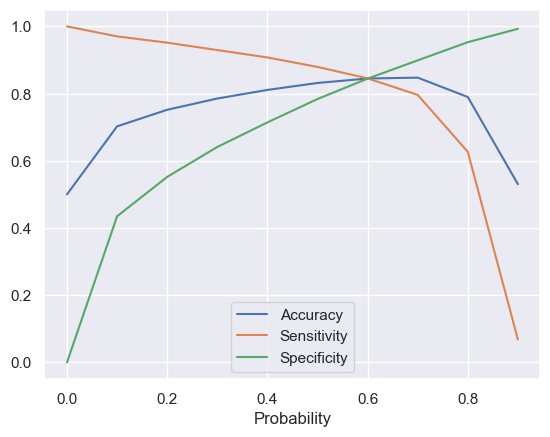

In [133]:
cutoff_df.plot.line(x='Probability',y=['Accuracy', 'Sensitivity','Specificity'])
plt.show()

From the curve above, 0.6 is the optimum point to take it as a cutoff probability.

Lets check precision-recall trade off

In [134]:
p, r, threshold = precision_recall_curve(churn_df.Churn, churn_df.Churn_Prob)

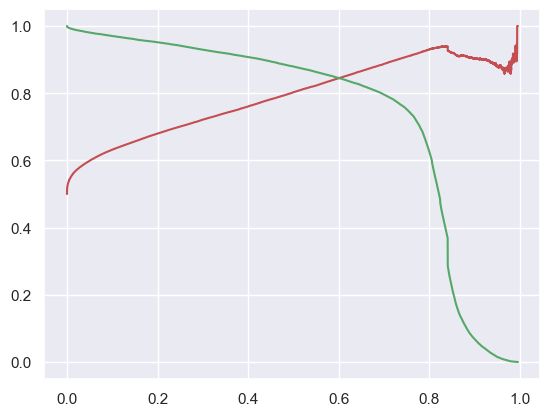

In [135]:
plt.plot(threshold, p[:-1],'r')
plt.plot(threshold, r[:-1],'g')
plt.show()

Even for Precision recall tradeoff, 0.6 seems to be the optimal value of cutoff

In [136]:
churn_df['Predicted'] = churn_df.Churn_Prob.apply(lambda x:1 if x>0.6 else 0)
churn_df.head()

,Churn,Churn_Prob,CustID,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,Predicted
0,0,0.226632,0,1,1,1,0,0,0,0,0,0,0,0
1,0,0.023797,1,1,0,0,0,0,0,0,0,0,0,0
2,0,0.010920,2,1,0,0,0,0,0,0,0,0,0,0
3,0,0.066713,3,1,0,0,0,0,0,0,0,0,0,0
4,0,0.119138,4,1,1,0,0,0,0,0,0,0,0,0


In [137]:
accuracy_score, confusion_matrix, precision_score, recall_score = evaluate_model_perf(churn_df.Predicted,churn_df.Churn)

Accuracy score: 0.84
Confusion matrix:
 [[37127  6839]
 [ 6802 37164]]
Precision score: 0.84
Recall score: 0.85


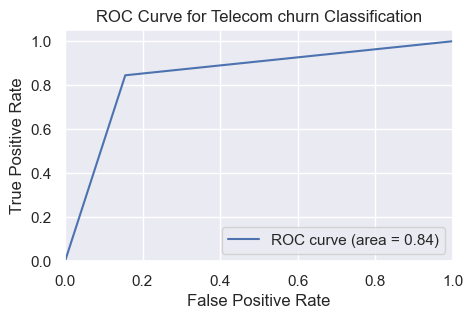

In [138]:
roc_auc = plot_roc_curve(churn_df.Churn, churn_df.Predicted)

In [213]:
model1_training_stats = {"Model": "GLM", "Accuracy": accuracy_score, "Precision":precision_score, "Recall":recall_score, "AUC": roc_auc }
model_training_stats_df = pd.concat([model_training_stats_df, pd.DataFrame([model1_training_stats])], ignore_index=True)

##### 3.1.4 Making Predictions on Test Data

In [140]:
X_test_m1 = X_test[rfe_col]
X_test_m1.shape

(21000, 14)

In [141]:
y_test_pred = predict_model_performance(res, sm.add_constant(X_test_m1))
y_test_pred.head()

3425     0.910913
33067    0.938790
52420    0.820314
5220     0.448066
33958    0.799245
dtype: float64

In [142]:
y_test_pred = y_test_pred.values.reshape(-1)

In [143]:
churn_df_test = pd.DataFrame()
churn_df_test['Churn']=y_test.values
churn_df_test['Churn_Prob']=y_test_pred
churn_df_test['CustID']=y_test.index
churn_df_test['Predicted']= churn_df_test.Churn_Prob.apply(lambda x: 1 if x > 0.6 else 0)
churn_df_test.head()

,Churn,Churn_Prob,CustID,Predicted
0,1,0.910913,3425,1
1,1,0.938790,33067,1
2,0,0.820314,52420,1
3,0,0.448066,5220,0
4,1,0.799245,33958,1


Model Evaluation on Test Data

In [144]:
accuracy_score_test, confusion_matrix_test, precision_score_test, recall_score_test = evaluate_model_perf(churn_df_test.Predicted,churn_df_test.Churn)

Accuracy score: 0.84
Confusion matrix:
 [[16000  2901]
 [  380  1719]]
Precision score: 0.37
Recall score: 0.82


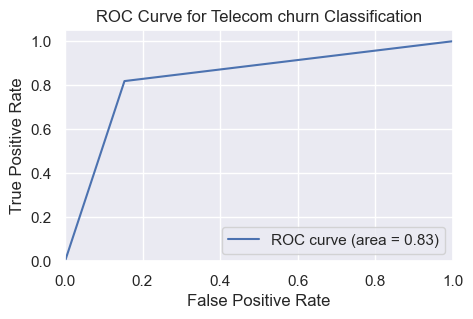

In [145]:
roc_auc_test = plot_roc_curve(churn_df_test.Churn, churn_df_test.Predicted)

In [146]:
model1_test_stats = {"Model": "GLM", "Accuracy": accuracy_score_test, "Precision":precision_score_test, "Recall":recall_score_test, "AUC":roc_auc_test }
model_test_stats_df = pd.concat([model_test_stats_df, pd.DataFrame([model1_test_stats])], ignore_index=True)

##### Model Performance results

##### --------------- Model 1: Logistic Regression without PCA - Interpretable Model -----------

In [147]:
print_evaluation_metrics(accuracy_score, confusion_matrix, precision_score, recall_score, accuracy_score_test,confusion_matrix_test,precision_score_test,recall_score_test)


      Metric  Train Data  Test Data
0   Accuracy    0.840000   0.840000
1       TN %    0.844448   0.846516
2       FP %    0.155552   0.153484
3       FN %    0.154710   0.181039
4      TP %     0.845290   0.818961
5  Precision    0.840000   0.370000
6     Recall    0.850000   0.820000


#### <font color='black' size=3.2>3.2 PCA for Dimensionality Reduction</font>

Since the number of columns are huge, need to perform PCA for better analysis and Model performance

In [148]:
pca = PCA(random_state=100)

In [149]:
pca.fit(X_train_smote)

PCA(random_state=100)

In [150]:
#Principal components
pca.components_

array([[ 1.56836673e-01,  1.86183115e-01,  1.68227552e-01, ...,
         1.24967013e-01,  1.49616684e-01,  4.51342901e-02],
       [-8.71001380e-02, -9.05502323e-02, -5.28826993e-02, ...,
         3.61288655e-02,  4.22056314e-02,  5.15697214e-03],
       [-7.57736591e-02, -5.26621675e-02,  1.20837380e-02, ...,
        -2.41782139e-02, -7.18438135e-02,  2.19716040e-01],
       ...,
       [-0.00000000e+00, -2.02156176e-17,  8.68786371e-20, ...,
         7.80339898e-18, -2.53747068e-17,  1.23924771e-18],
       [ 0.00000000e+00,  1.26211401e-17,  3.14910770e-17, ...,
        -6.43669649e-17, -9.33132596e-19, -5.67679223e-18],
       [ 0.00000000e+00, -3.27894929e-16, -1.21062596e-15, ...,
        -9.09461161e-16,  2.03563580e-15,  4.35358158e-17]])

In [151]:
pca.explained_variance_ratio_

array([1.71341035e-01, 1.10158816e-01, 6.82113271e-02, 4.87167210e-02,
       4.42522754e-02, 3.05555312e-02, 2.66389419e-02, 2.62855645e-02,
       2.55240304e-02, 2.44795077e-02, 2.15700306e-02, 2.14409783e-02,
       1.70912782e-02, 1.46309683e-02, 1.39434424e-02, 1.27849913e-02,
       1.24208342e-02, 1.15114264e-02, 1.07827076e-02, 1.02457244e-02,
       9.88364307e-03, 9.56816678e-03, 9.37880286e-03, 9.21093458e-03,
       9.08020699e-03, 8.12649868e-03, 8.06157342e-03, 7.88814572e-03,
       7.55908114e-03, 7.42009362e-03, 7.04867653e-03, 6.63665118e-03,
       6.29222500e-03, 5.93172404e-03, 5.69867130e-03, 5.51852830e-03,
       5.44140652e-03, 5.24104836e-03, 5.14755207e-03, 4.95965858e-03,
       4.81735197e-03, 4.70604552e-03, 4.66120341e-03, 4.51899012e-03,
       4.35211294e-03, 4.21837269e-03, 4.12693824e-03, 3.76982298e-03,
       3.67303869e-03, 3.61331457e-03, 3.29547247e-03, 3.12600670e-03,
       3.00410192e-03, 2.83662660e-03, 2.81886577e-03, 2.57442898e-03,
      

Scree Plot to determine the number of principle components required to explain maximum variance

In [152]:
var_cumu = np.cumsum(pca.explained_variance_ratio_)

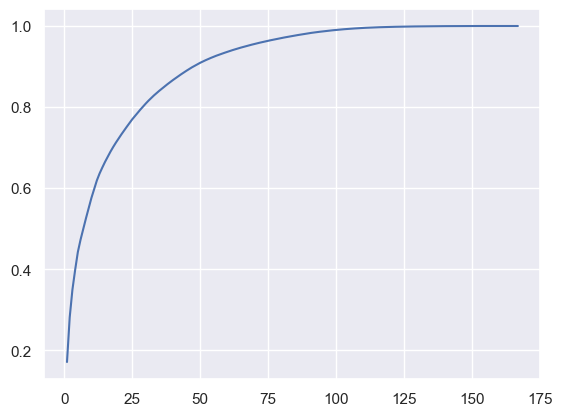

In [153]:
plt.plot(range(1,len(var_cumu)+1), var_cumu)
plt.show()

From the above scree plot we could see that aboot 98% of variance is explained by 75 principle components. So lets use this number for dimentionality reduction

In [154]:
pc2 = PCA(n_components=75, random_state=100)

In [155]:
X_train_pca = pc2.fit_transform(X_train_smote)

In [156]:
print("Original Variables: ",X_train_smote.shape)
print("Principal Components: ", X_train_pca.shape)

Original Variables:  (87932, 167)
Principal Components:  (87932, 75)


In [157]:
X_train_pca_df = pd.DataFrame(X_train_pca)
X_train_pca_df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
0,0.491017,1.138409,-0.785027,-1.546869,1.344329,0.274541,-0.215530,0.791663,0.010703,0.614348,...,-0.127169,0.018557,-0.041344,0.021057,-0.117756,0.017500,0.014700,-0.027904,0.144783,-0.124646
1,-0.220805,-0.077261,0.747121,-0.116769,0.058154,0.099148,0.014558,-0.479961,0.161053,0.270916,...,0.005154,-0.033472,0.040329,-0.091244,-0.002977,0.067220,-0.015118,0.080425,0.081618,-0.009785
2,1.201944,-1.053645,0.780396,0.105897,0.028643,0.075313,-0.461501,0.330906,-0.303302,-0.171219,...,0.021729,-0.010007,-0.018281,-0.028735,-0.005243,-0.055830,0.018645,-0.024911,-0.093576,-0.004159
3,-0.394133,0.066785,0.355703,-0.141535,-0.466059,0.040206,-0.094648,0.135533,0.245357,0.290501,...,0.007609,-0.015539,0.074161,0.032800,-0.009920,-0.025363,0.049189,-0.040709,0.013682,-0.003371
4,-0.244509,-0.022919,0.773730,0.245822,0.042475,0.053413,-0.059017,0.191991,0.079845,0.183181,...,0.002723,-0.026772,0.139160,0.090621,0.019105,0.101040,0.047822,-0.058930,-0.051384,-0.040890


In [158]:
X_test_pca = pc2.transform(X_test)
X_test_pca_df = pd.DataFrame(X_test_pca)
X_test_pca_df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
0,-0.125156,-0.525500,-0.473644,-0.324755,-0.213282,0.024943,-0.092357,-0.134080,0.190873,-0.260422,...,0.027208,-0.027801,0.012625,0.018807,-0.019284,0.011625,-0.044451,-0.060223,0.177246,-0.050845
1,0.767066,-0.835157,-0.213691,0.547448,0.422519,0.051438,0.827519,0.452996,-0.639595,-0.216198,...,0.119776,-0.026759,-0.123676,-0.064529,0.029465,-0.025806,0.019425,0.053972,-0.207576,-0.014922
2,-0.691601,0.104940,-0.101335,0.126221,-0.065839,0.044675,0.146809,0.152879,-0.191223,0.006681,...,0.097754,-0.021790,0.023901,-0.008839,-0.033386,0.057065,-0.018287,-0.008008,0.045455,0.012807
3,-0.220049,0.810582,-0.027007,-0.211245,-0.308446,0.107632,-0.296249,0.137451,0.097391,0.034449,...,-0.094049,0.004960,0.036190,0.029268,-0.000889,0.032062,-0.048620,-0.016667,-0.031223,0.014238
4,-0.568465,-0.037736,-0.016176,-0.193053,-0.190463,0.042234,-0.012418,-0.028441,0.105169,-0.086814,...,0.009616,0.022466,0.012928,0.015565,0.006604,0.009880,0.034952,0.033310,-0.026893,0.016258


#### <font color='black' size=3.2>3.3 Model2: Decision trees (With PCA and HyperParameter Tuning) </font>

##### 3.3.1 Find Optimal value for hyper parameters

In [159]:
params = {
    "criterion" : ['gini', 'entropy'],
    "max_depth": [5,10,20,40],
    "min_samples_leaf": [10,50,100,500]
}

In [160]:
dt = DecisionTreeClassifier(random_state=100)

In [161]:
grid_search = GridSearchCV(estimator=dt,
                           param_grid=params,
                           cv=5,
                           n_jobs=-1, verbose=1, scoring="accuracy")

In [162]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
CPU times: total: 17.9 s
Wall time: 4min 55s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=100),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, 40],
                         'min_samples_leaf': [10, 50, 100, 500]},
             scoring='accuracy', verbose=1)

In [163]:
grid_search.best_score_

0.8635424011632095

In [164]:
dt_best = grid_search.best_estimator_
dt_best

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=10,
                       random_state=100)

##### 3.3.2 Create a Decision tree model with Optimal value for hyper parameters

In [165]:
model2 = DecisionTreeClassifier(random_state=99,criterion='entropy', max_depth=20, min_samples_leaf=10)

In [166]:
model2.fit(X_train_pca_df, y_train_smote)

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=10,
                       random_state=99)

##### 3.3.3 Model Prediction on Training Data

In [167]:
y_train_pred_m2 = predict_model_performance(model2,X_train_pca_df)

In [168]:
accuracy_score_m2, confusion_matrix_m2, precision_score_m2, recall_score_m2 = evaluate_model_perf(y_train_pred_m2,y_train_smote)

Accuracy score: 0.95
Confusion matrix:
 [[41714  2252]
 [ 2409 41557]]
Precision score: 0.95
Recall score: 0.95


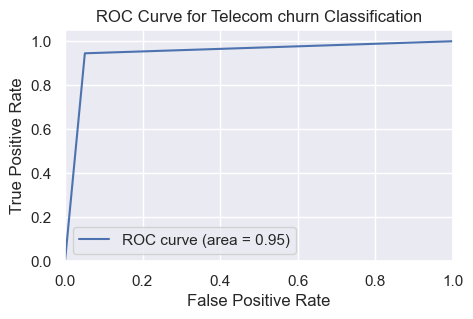

In [169]:
roc_auc_m2 = plot_roc_curve(y_train_smote,y_train_pred_m2)

In [214]:
model2_training_stats = {"Model": "Decision Tree", "Accuracy": accuracy_score_m2, "Precision":precision_score_m2, 
                         "Recall":recall_score_m2, "AUC": roc_auc_m2 }
model_training_stats_df = pd.concat([model_training_stats_df, pd.DataFrame([model2_training_stats])], ignore_index=True)

##### 3.3.4 Model Prediction on Test Data

In [171]:
y_test_pred_m2 = predict_model_performance(model2, X_test_pca_df)

In [172]:
accuracy_score_test_m2, confusion_matrix_test_m2, precision_score_test_m2, recall_score_test_m2 = evaluate_model_perf(y_test_pred_m2,y_test)

Accuracy score: 0.84
Confusion matrix:
 [[16327  2574]
 [  808  1291]]
Precision score: 0.33
Recall score: 0.62


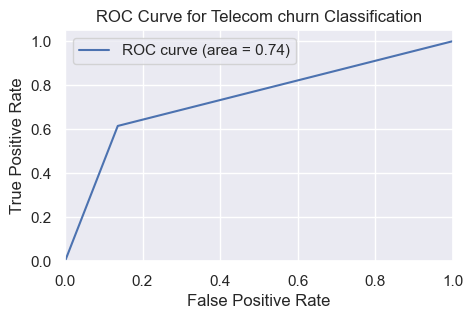

In [173]:
roc_auc_test_m2 = plot_roc_curve(y_test, y_test_pred_m2)

In [174]:
model2_test_stats = {"Model": "Decision Tree", "Accuracy": accuracy_score_test_m2, "Precision":precision_score_test_m2, "Recall":recall_score_test_m2, "AUC":roc_auc_test_m2 }
model_test_stats_df = pd.concat([model_test_stats_df, pd.DataFrame([model2_test_stats])], ignore_index=True)

##### 3.3.5 Model Performance results

##### --------------- Model2: Decision Trees with PCA -----------

In [175]:
print_evaluation_metrics(accuracy_score_m2, confusion_matrix_m2, precision_score_m2, recall_score_m2, accuracy_score_test_m2,
                         confusion_matrix_test_m2,precision_score_test_m2,recall_score_test_m2)


      Metric  Train Data  Test Data
0   Accuracy    0.950000   0.840000
1       TN %    0.948779   0.863817
2       FP %    0.051221   0.136183
3       FN %    0.054792   0.384945
4      TP %     0.945208   0.615055
5  Precision    0.950000   0.330000
6     Recall    0.950000   0.620000


#### As we could see from the above statistics, Decision Tree has overfitted on the Train data

#### <font color='black' size=3.2>3.4 Model 3: Random Forests (With PCA and HyperParameter Tuning) </font>

##### 3.4.1 Find Optimal value for n_estimators

In [183]:
rf_nestimators = RandomForestClassifier(random_state=25, n_jobs=-1, oob_score=True,class_weight='balanced')

In [192]:
params = {
    'n_estimators': [10, 30, 50, 100, 200]
}

In [185]:
grid_search = GridSearchCV(estimator=rf_nestimators, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [186]:
print(X_train_pca_df.shape)
print(y_train_smote.shape)

(87932, 75)
(87932,)


In [187]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
CPU times: total: 7min 42s
Wall time: 7min 19s


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, oob_score=True,
                                              random_state=25),
             n_jobs=-1, param_grid={'n_estimators': [10, 30, 50, 100, 200]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [188]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'n_estimators': 200}
0.949790747395715
RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=25)


##### 3.4.2 Find Optimal value for max_depth

In [191]:
rf_maxDepth = RandomForestClassifier(random_state=12, n_jobs=-1, oob_score=True,class_weight='balanced',n_estimators=200)

In [195]:
params = {
    'max_depth': [10,20,40]
}

In [196]:
grid_search = GridSearchCV(estimator=rf_maxDepth, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [197]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 7min 46s
Wall time: 8min 52s


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=200, n_jobs=-1,
                                              oob_score=True, random_state=12),
             n_jobs=-1, param_grid={'max_depth': [10, 20, 40]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [198]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'max_depth': 40}
0.9494609470954829
RandomForestClassifier(class_weight='balanced', max_depth=40, n_estimators=200,
                       n_jobs=-1, oob_score=True, random_state=12)


##### 3.4.3 Find Optimal value for min_samples_leaf

In [199]:
rf_minSampleLeaf = RandomForestClassifier(random_state=40, n_jobs=-1, oob_score=True,class_weight='balanced',n_estimators=200,
                                         max_depth=40)

In [200]:
params = {
    'min_samples_leaf': [10,50,100]
}

In [201]:
grid_search = GridSearchCV(estimator=rf_minSampleLeaf, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [202]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 6min 39s
Wall time: 7min 39s


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=40, n_estimators=200,
                                              n_jobs=-1, oob_score=True,
                                              random_state=40),
             n_jobs=-1, param_grid={'min_samples_leaf': [10, 50, 100]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [203]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'min_samples_leaf': 10}
0.917004048582996
RandomForestClassifier(class_weight='balanced', max_depth=40,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=40)


##### 3.4.4 Fine Tuned Random Forest model

In [205]:
model3  = RandomForestClassifier(random_state=18, n_jobs=-1,oob_score=True,class_weight='balanced',n_estimators=200,
                                         max_depth=40,min_samples_leaf=10 )

In [206]:
model3.fit(X_train_pca_df, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=40,
                       min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=18)

##### 3.4.5 Model Prediction on Training Data

In [207]:
y_train_pred_m3 = predict_model_performance(model3,X_train_pca_df)

In [208]:
accuracy_score_m3, confusion_matrix_m3, precision_score_m3, recall_score_m3 = evaluate_model_perf(y_train_pred_m3,y_train_smote)

Accuracy score: 0.97
Confusion matrix:
 [[42252  1714]
 [ 1019 42947]]
Precision score: 0.96
Recall score: 0.98


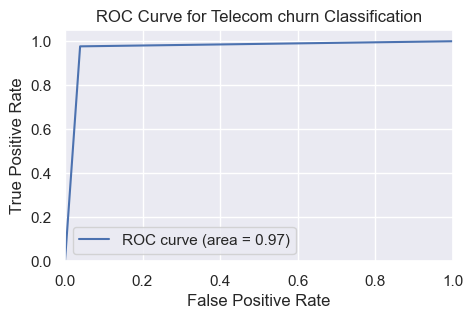

In [209]:
roc_auc_m3 = plot_roc_curve(y_train_smote,y_train_pred_m3)

In [215]:
model3_training_stats = {"Model": "Random Forest", "Accuracy": accuracy_score_m3, "Precision":precision_score_m3, 
                         "Recall":recall_score_m3, "AUC": roc_auc_m3 }
model_training_stats_df = pd.concat([model_training_stats_df, pd.DataFrame([model3_training_stats])], ignore_index=True)

##### 3.4.6 Model Prediction on Test Data

In [217]:
y_test_pred_m3 = predict_model_performance(model3, X_test_pca_df)

In [218]:
accuracy_score_test_m3, confusion_matrix_test_m3, precision_score_test_m3, recall_score_test_m3 = evaluate_model_perf(y_test_pred_m3,y_test)

Accuracy score: 0.9
Confusion matrix:
 [[17460  1441]
 [  665  1434]]
Precision score: 0.5
Recall score: 0.68


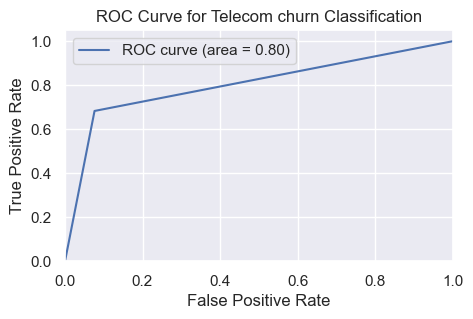

In [221]:
roc_auc_test_m3 = plot_roc_curve(y_test, y_test_pred_m3)

In [222]:
model3_test_stats = {"Model": "Random Forest", "Accuracy": accuracy_score_test_m3, "Precision":precision_score_test_m3, "Recall":recall_score_test_m3, "AUC":roc_auc_test_m3 }
model_test_stats_df = pd.concat([model_test_stats_df, pd.DataFrame([model3_test_stats])], ignore_index=True)

##### 3.4.7 Model Performance results

##### --------------- Model 3: Random Forest with PCA -----------

In [220]:
print_evaluation_metrics(accuracy_score_m3, confusion_matrix_m3, precision_score_m3, recall_score_m3, accuracy_score_test_m3,confusion_matrix_test_m3,precision_score_test_m3,recall_score_test_m3)


      Metric  Train Data  Test Data
0   Accuracy    0.970000   0.900000
1       TN %    0.961015   0.923761
2       FP %    0.038985   0.076239
3       FN %    0.023177   0.316818
4      TP %     0.976823   0.683182
5  Precision    0.960000   0.500000
6     Recall    0.980000   0.680000


#### <font color='black' size=3.2>3.5 Model 4: Ada Boosting (With PCA and HyperParameter Tuning) </font>

##### 3.5.1 Find Optimal value for hyper parameters

In [226]:
adaboost =  AdaBoostClassifier(random_state=88)

In [230]:
params = {
    'n_estimators': [50,100,200]
}

In [231]:
grid_search = GridSearchCV(estimator=adaboost, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [232]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 4min 20s
Wall time: 12min


GridSearchCV(cv=4, estimator=AdaBoostClassifier(random_state=88), n_jobs=-1,
             param_grid={'n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [233]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'n_estimators': 200}
0.8494063594595824
AdaBoostClassifier(n_estimators=200, random_state=88)


##### 3.5.2 Fine Tuned AdaBoost model

In [234]:
model4 = AdaBoostClassifier(random_state=78,n_estimators=200)

In [236]:
model4.fit(X_train_pca_df, y_train_smote)

AdaBoostClassifier(n_estimators=200, random_state=78)

##### 3.5.3 Model Prediction on Training Data

In [237]:
y_train_pred_m4 = predict_model_performance(model4,X_train_pca_df)

In [238]:
accuracy_score_m4, confusion_matrix_m4, precision_score_m4, recall_score_m4 = evaluate_model_perf(y_train_pred_m4,y_train_smote)

Accuracy score: 0.86
Confusion matrix:
 [[37039  6927]
 [ 5686 38280]]
Precision score: 0.85
Recall score: 0.87


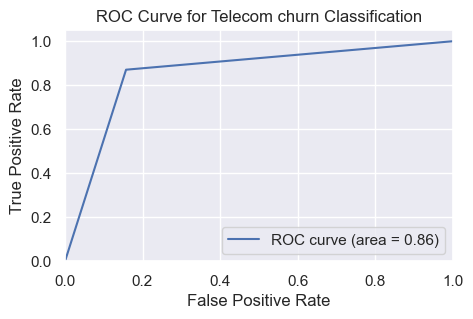

In [239]:
roc_auc_m4 = plot_roc_curve(y_train_smote,y_train_pred_m4)

In [240]:
model4_training_stats = {"Model": "AdaBoost", "Accuracy": accuracy_score_m4, "Precision":precision_score_m4, 
                         "Recall":recall_score_m4, "AUC": roc_auc_m4 }
model_training_stats_df = pd.concat([model_training_stats_df, pd.DataFrame([model4_training_stats])], ignore_index=True)

##### 3.5.4 Model Prediction on Test Data

In [242]:
y_test_pred_m4 = predict_model_performance(model4, X_test_pca_df)

In [243]:
accuracy_score_test_m4, confusion_matrix_test_m4, precision_score_test_m4, recall_score_test_m4 = evaluate_model_perf(y_test_pred_m4,y_test)

Accuracy score: 0.83
Confusion matrix:
 [[15783  3118]
 [  408  1691]]
Precision score: 0.35
Recall score: 0.81


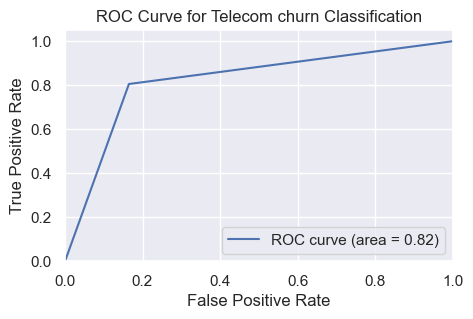

In [245]:
roc_auc_test_m4 = plot_roc_curve(y_test, y_test_pred_m4)

In [246]:
model4_test_stats = {"Model": "AdaBoost", "Accuracy": accuracy_score_test_m4, "Precision":precision_score_test_m4, "Recall":recall_score_test_m4, "AUC":roc_auc_test_m4 }
model_test_stats_df = pd.concat([model_test_stats_df, pd.DataFrame([model4_test_stats])], ignore_index=True)

##### 3.4.5 Model Performance results

##### --------------- Model 4: AdaBoost with PCA -----------

In [248]:
print_evaluation_metrics(accuracy_score_m4, confusion_matrix_m4, precision_score_m4, recall_score_m4, accuracy_score_test_m4,confusion_matrix_test_m4,precision_score_test_m4,recall_score_test_m4)


      Metric  Train Data  Test Data
0   Accuracy    0.860000   0.830000
1       TN %    0.842446   0.835035
2       FP %    0.157554   0.164965
3       FN %    0.129327   0.194378
4      TP %     0.870673   0.805622
5  Precision    0.850000   0.350000
6     Recall    0.870000   0.810000


#### <font color='black' size=3.2>3.6 Model 5: XGBoost (With PCA and HyperParameter Tuning) </font>

##### 3.6.1 Find Optimal value for n_estimators

In [14]:
import sklearn

In [16]:
print(xgb.__version__)
print(sklearn.__version__)

2.0.3
1.2.2


In [251]:
xgboost = XGBClassifier(random_state=54)

In [252]:
params = {
    'n_estimators': [50,100,200]
}

In [253]:
grid_search = GridSearchCV(estimator=xgboost, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [254]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 30.3 s
Wall time: 42.7 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=54, ...),
             n_jobs=-1, param_grid={'n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [255]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'n_estimators': 200}
0.9484374289223492
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=54, ...)


##### 3.6.2 Find Optimal value for learning_rate

In [258]:
xgboost = XGBClassifier(random_state=66, n_estimators=200)
params = {
    'learning_rate': [0.3,0.5,0.7]
}
grid_search = GridSearchCV(estimator=xgboost, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [259]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 34.8 s
Wall time: 57.3 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=66, ...),
             n_jobs=-1, param_grid={'learning_rate': [0.3, 0.5, 0.7]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [260]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'learning_rate': 0.5}
0.9534299231224128
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=66, ...)


##### 3.6.3 Find Optimal value for max_depth

In [261]:
xgboost = XGBClassifier(random_state=78, n_estimators=200,learning_rate=0.5 )
params = {
    'max_depth': [10,20,40]
}
grid_search = GridSearchCV(estimator=xgboost, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [262]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 1min 18s
Wall time: 52.7 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.5, m...,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=78, ...),
             n_jobs=-1, param_grid={'max_depth': [10, 20, 40]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [263]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'max_depth': 10}
nan
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=78, ...)


##### 3.6.4 Find Optimal value for subsample

In [265]:
xgboost = XGBClassifier(random_state=97, n_estimators=200,learning_rate=0.5,max_depth=10 )
params = {
    'subsample': [0.3,0.5,0.7]
}
grid_search = GridSearchCV(estimator=xgboost, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, return_train_score=True,
                           scoring = "accuracy")

In [266]:
%%time
grid_search.fit(X_train_pca_df, y_train_smote)

Fitting 4 folds for each of 3 candidates, totalling 12 fits
CPU times: total: 1min 16s
Wall time: 1min 39s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.5, m...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=10,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=97, ...),
             n_jobs=-1, param_grid={'subsample': [0.3, 0.5, 0.7]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [267]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'subsample': 0.7}
0.9567165537005868
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=97, ...)


##### 3.6.5 Fine Tuned XGBoost model

In [287]:
model5 = XGBClassifier(random_state=94, n_estimators=200,learning_rate=0.5,max_depth=10,subsample=0.7)

In [288]:
model5.fit(X_train_pca_df, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=94, ...)

##### 3.6.6 Model Prediction on Training Data

In [289]:
y_train_pred_m5 = predict_model_performance(model5,X_train_pca_df)

In [290]:
accuracy_score_m5, confusion_matrix_m5, precision_score_m5, recall_score_m5 = evaluate_model_perf(y_train_pred_m5,y_train_smote)

Accuracy score: 1.0
Confusion matrix:
 [[43966     0]
 [    0 43966]]
Precision score: 1.0
Recall score: 1.0


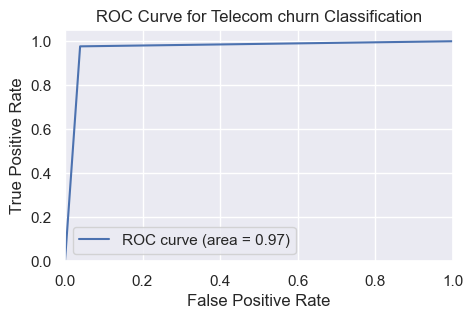

In [291]:
roc_auc_m5 = plot_roc_curve(y_train_smote,y_train_pred_m3)

In [304]:
model5_training_stats = {"Model": "XGBoost", "Accuracy": accuracy_score_m5, "Precision":precision_score_m5, 
                         "Recall":recall_score_m5, "AUC": roc_auc_m5 }
model_training_stats_df = pd.concat([model_training_stats_df, pd.DataFrame([model5_training_stats])], ignore_index=True)

##### 3.6.7 Model Prediction on Test Data

In [293]:
y_test_pred_m5 = predict_model_performance(model5, X_test_pca_df)

In [294]:
accuracy_score_test_m5, confusion_matrix_test_m5, precision_score_test_m5, recall_score_test_m5 = evaluate_model_perf(y_test_pred_m5,y_test)

Accuracy score: 0.91
Confusion matrix:
 [[17733  1168]
 [  778  1321]]
Precision score: 0.53
Recall score: 0.63


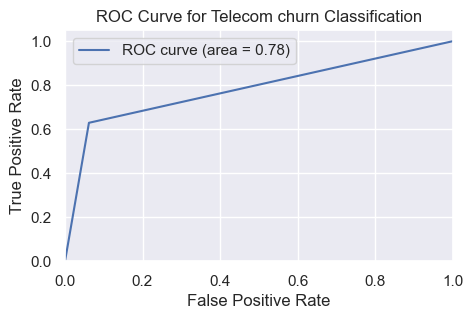

In [297]:
roc_auc_test_m5 = plot_roc_curve(y_test, y_test_pred_m5)

In [298]:
model5_test_stats = {"Model": "XGBoost", "Accuracy": accuracy_score_test_m5, "Precision":precision_score_test_m5, "Recall":recall_score_test_m5, "AUC":roc_auc_test_m5 }
model_test_stats_df = pd.concat([model_test_stats_df, pd.DataFrame([model5_test_stats])], ignore_index=True)

#### <font color='#000080' size=5>***4. Model Performance Summary:***</font>

#### <font color='black' size=3.2>4.1 Model Performance on Training Data </font>

In [305]:
model_training_stats_df

,Model,Accuracy,Precision,Recall,AUC
0,GLM,0.84,0.84,0.85,0.84
1,Decision Tree,0.95,0.95,0.95,0.95
2,Random Forest,0.97,0.96,0.98,0.97
3,AdaBoost,0.86,0.85,0.87,0.86
4,XGBoost,1.00,1.00,1.00,0.97


#### <font color='black' size=3.2>4.2 Model Performance on Test Data </font>

In [306]:
model_test_stats_df

,Model,Accuracy,Precision,Recall,AUC
0,GLM,0.84,0.37,0.82,0.83
1,Decision Tree,0.84,0.33,0.62,0.74
2,Random Forest,0.90,0.50,0.68,0.80
3,AdaBoost,0.83,0.35,0.81,0.82
4,XGBoost,0.91,0.53,0.63,0.78


#### <font color='#000080' size=5>***5. Recommendations:***</font>

#### <font color='black' size=3.2>5.1 Model Prediction </font>

- Objective of this modelling is to predict whether the customer will churn or not, in near future. By knowing this, the company can take action steps such as providing special plans, discounts on recharge.
</br>
So, the metrics for evaluating model performance will be recall and AUC score rather than overall accuracy of the model, so that majority of the customers will be identified who will churn.
</br>
Since there was huge class imbalance, AUC also be a better metric for model evaluation

- As per the Model performance summary we see that DecisionTree and XGBoost has clear overfitting and hence cannot be considered for prediction.
</br>
Logistic Regression, AdaBoost and RandomForest seems to perform well. However on comparing train and test scores, we see that RandomForest has high bias comparatively.

- So, for this Telcom churn prediction we can choose AdaBoost classifier Model (Model 4) as the best fit model with the below configurations
</br>
PCA - No. of principle components chosen - 75
</br>
SMOTE - For handling class imbalance (on Train dataset)
</br>
HyperParameters - n_estimators=200

- Below is the Performance summary of AdaBoost Model on Test Data

In [308]:
print("Accuracy : ",accuracy_score_test_m4, "\nRecall : ", recall_score_test_m4, "\nAUC : ", roc_auc_test_m4, "\nPrecision : ", precision_score_test_m4 )

Accuracy :  0.83 
Recall :  0.81 
AUC :  0.82 
Precision :  0.35


- However if accuracy is the mertic for perforamce, we can clearly go with Randomforest model (Model3 - with the below configurations)
</br>
PCA - No. of principle components chosen - 75
</br>
SMOTE - For handling class imbalance (on Train dataset)
</br>
HyperParameters -n_estimators=200,max_depth=40,min_samples_leaf=10

- Below is the Performance summary of RandomForest Model on Test Data

In [312]:
print("Accuracy : ",accuracy_score_test_m3, "\nRecall : ", recall_score_test_m3, "\nAUC : ", roc_auc_test_m3, "\nPrecision : ", precision_score_test_m3)

Accuracy :  0.9 
Recall :  0.68 
AUC :  0.8 
Precision :  0.5


#### <font color='black' size=3.2>5.2 Strong Predictors of churn </font>

Below are the top 10 features that are found to be strong predictors of churn

- loc_ic_t2m_mou_8 - Minutes of usage on local incoming calls from other mobile operator for the month of August
- spl_ic_mou_8 - Minutes of usage on special incoming calls in the month of August
- loc_ic_t2f_mou_8 - Minutes of usage on local incoming calls from same operator (Fixed lines) for the month of August
- av_rech_amt_data_8 - Average recharge amount for the month of August (Both calls and data)
- total_rech_num_8 - Total recharges done in the month of August
- loc_og_t2t_mou_8 - Minutes of usage on local outgoing calls within the same operator in the month of August 
- last_day_rch_amt_8 - Last day recharge amount in the month of August 
- arpu_3g_8 - Average revenue per user for 3G services in the month of August
- loc_ic_t2t_mou_8 - Minutes of usage on local incoming calls within the same operator in the month of August 
- arpu_7 - Average revenue per user in the month of July

Below is the details on how well these features affect the churn proability

- loc_ic_t2m_mou_8 - For every unit in decrease of loc_ic_t2m_mou_8, it increases the probability of churn by 10 units
- spl_ic_mou_8 - For every unit in decrease of spl_ic_mou_8, it increases the probability of churn by 5 units
- loc_ic_t2f_mou_8 - For every unit in decrease of loc_ic_t2f_mou_8, it increases the probability of churn by 5 units
- av_rech_amt_data_8 - For every unit in decrease of av_rech_amt_data_8, it increases the probability of churn by 4 units
- total_rech_num_8 - For every unit in decrease of total_rech_num_8, it increases the probability of churn by 4 units
- loc_og_t2t_mou_8 - For every unit in decrease of loc_og_t2t_mou_8, it increases the probability of churn by 4 units 
- last_day_rch_amt_8 - For every unit in decrease of last_day_rch_amt_8, it increases the probability of churn by 4 units
- arpu_3g_8 - For every unit in increase of arpu_3g_8, it increases the probability of churn by 3 units
- loc_ic_t2t_mou_8 - For every unit in decrease of loc_ic_t2t_mou_8, it increases the probability of churn by 2 units 
- arpu_7 - For every unit in increase of arpu_7, it increases the probability of churn by 2 units

#### <font color='black' size=3.2>5.3 Model selection for different Use cases </font>

##### 5.3.1 Usecase1: ML model that identifies customers who'll definitely churn with more accuracy

- For the above usecase, we need to chose the model with better recall which defines what proportion of actual positives are identified correctly. 

- So, best fit model for this usecase will be AdaBoost classifier with the following configurations
</br>
PCA - No. of principle components chosen - 75
</br>
SMOTE - For handling class imbalance (on Train dataset)
</br>
HyperParameters - n_estimators=200

- Below is the model summary on train and test data

In [314]:
print_evaluation_metrics(accuracy_score_m4, confusion_matrix_m4, precision_score_m4, recall_score_m4, accuracy_score_test_m4,confusion_matrix_test_m4,precision_score_test_m4,recall_score_test_m4)


      Metric  Train Data  Test Data
0   Accuracy    0.860000   0.830000
1       TN %    0.842446   0.835035
2       FP %    0.157554   0.164965
3       FN %    0.129327   0.194378
4      TP %     0.870673   0.805622
5  Precision    0.850000   0.350000
6     Recall    0.870000   0.810000


- Here is the summary on the same
</br>
If the model predicts that customer will churn, it is correct 35% of the time
</br>
Model correclty identifies 81% of churn customers
</br>
This means strategies that will be employed to retain the customers might be appliable to few non-churn customers as well

##### 5.3.2 Usecase2: ML model that identifies both the churn and non-churn customers correctly

- For the above usecase, we need to chose the model with better overall accuracy

- So, best fit model for this usecase will be RandomForest classifier with the following configurations
</br>
PCA - No. of principle components chosen - 75
</br>
SMOTE - For handling class imbalance (on Train dataset)
</br>
HyperParameters -n_estimators=200,max_depth=40,min_samples_leaf=10

- Below is the model summary on train and test data

In [317]:
print_evaluation_metrics(accuracy_score_m3, confusion_matrix_m3, precision_score_m3, recall_score_m3, accuracy_score_test_m3,confusion_matrix_test_m3,precision_score_test_m3,recall_score_test_m3)


      Metric  Train Data  Test Data
0   Accuracy    0.970000   0.900000
1       TN %    0.961015   0.923761
2       FP %    0.038985   0.076239
3       FN %    0.023177   0.316818
4      TP %     0.976823   0.683182
5  Precision    0.960000   0.500000
6     Recall    0.980000   0.680000


- Here is the summary on the same
</br>
Model predicts the churn and non churn customers with overall accuracy of 90%
</br>
We can see a better balance between Precision and Recall
</br>

#### <font color='black' size=3.2>5.4 Conclusion </font>

This project addressed two complementary business objectives: predicting customer churn and identifying the key factors contributing to churn behavior.
<br>
<br>
To improve predictive performance on an imbalanced dataset, SMOTE was applied to the training data and Principal Component Analysis (PCA) was used for dimensionality reduction. Multiple classification algorithms including Logistic Regression, Decision Tree, Random Forest, AdaBoost, and XGBoost were evaluated.
</br>
</br>
The evaluation demonstrated that model selection depends on the business objective. For churn prediction, Recall and AUC were considered more important than overall accuracy because failing to identify a churn customer has a direct business impact.
</br>
</br>
AdaBoost emerged as the preferred model for churn prediction, achieving a Recall of 81% and an AUC of 82% on the test dataset. This indicates that the model successfully identified the majority of customers who were likely to churn, making it suitable for proactive retention campaigns.
</br>
</br>
For scenarios where balanced classification performance is required, Random Forest achieved the highest overall accuracy of 90% while maintaining reasonable Recall and Precision values.
</br>
</br>
To understand churn drivers, Logistic Regression was used to identify the most influential predictors. The analysis revealed that declining incoming call activity, reduced recharge behavior, lower customer engagement, and changes in revenue-related indicators were strongly associated with churn.
</br>
</br>
Overall, the project demonstrates how predictive modeling and customer behavior analysis can be combined to support targeted retention strategies and reduce customer attrition.

#### <font color='black' size=3.2>5.5 Recommended strategies </font>

#### High-Risk Customer Identification

Deploy the AdaBoost model to identify customers with a high probability of churn and prioritize them for retention campaigns.

#### Early Warning Indicators

Monitor customers showing:

- Declining incoming call activity
- Reduced recharge frequency
- Lower recharge amounts
- Decreasing local usage patterns
- Reduced data recharge activity

These variables emerged as strong predictors of churn.

#### Personalized Retention Offers

Customers exhibiting declining engagement should be targeted with:

- Customized recharge plans
- Loyalty rewards
- Bonus data packages
- Special promotional offers

#### Revenue Protection Strategy

Since multiple churn predictors are directly related to customer spending and recharge behavior, proactive intervention can help prevent revenue leakage before churn occurs.

#### Future Enhancements

- Evaluate advanced ensemble methods for further performance improvement.
- Investigate probability-based customer segmentation for prioritizing retention efforts.
- Develop real-time churn monitoring dashboards.
- Integrate customer support interactions and complaint history into churn prediction models.

#### <font color='#000080' size=5>***6. Creating submission file:***</font>

In [372]:
unseen_df = pd.read_csv("C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/test.csv")
sample_df = pd.read_csv("C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/sample.csv")

In [373]:
sample_df.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [374]:
unseen_df.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,...,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,...,0,0,0,NaN,NaN,NaN,2533,0.00,0.00,0.00
2,70001,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,329.844,434.884,...,0,0,0,NaN,NaN,NaN,277,525.61,758.41,241.84
3,70002,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,43.550,171.390,...,0,0,0,NaN,NaN,NaN,1244,0.00,0.00,0.00
4,70003,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,306.854,406.289,...,0,0,0,NaN,NaN,NaN,462,0.00,0.00,0.00


In [375]:
unseen_df.shape

(30000, 171)

#### <font color='black' size=3.2>6.1 Derived Metrics </font>

In [376]:
unseen_df.rename(columns = {'jun_vbc_3g':'vbc_3g_6', 'jul_vbc_3g':'vbc_3g_7',
                              'aug_vbc_3g':'vbc_3g_8'}, inplace = True)

In [377]:
date_vars = unseen_df.select_dtypes(include='object').columns
for col in date_vars:
    unseen_df[col] = pd.to_datetime(unseen_df[col],format='%m/%d/%Y')

unseen_df['day_of_last_rech_6'] = unseen_df['date_of_last_rech_6'].dt.day
unseen_df['day_of_last_rech_7'] = unseen_df['date_of_last_rech_7'].dt.day
unseen_df['day_of_last_rech_8'] = unseen_df['date_of_last_rech_8'].dt.day

unseen_df['day_of_last_rech_6'] = unseen_df['day_of_last_rech_6'].astype("Int64")
unseen_df['day_of_last_rech_7'] = unseen_df['day_of_last_rech_7'].astype("Int64")
unseen_df['day_of_last_rech_8'] = unseen_df['day_of_last_rech_8'].astype("Int64")


In [378]:
unseen_df['total_rech_amt_data_6'] = unseen_df['total_rech_data_6'] * unseen_df['av_rech_amt_data_6']
unseen_df['total_rech_amt_data_7'] = unseen_df['total_rech_data_7'] * unseen_df['av_rech_amt_data_7']
unseen_df['total_rech_amt_data_8'] = unseen_df['total_rech_data_8'] * unseen_df['av_rech_amt_data_8']
unseen_df['total_rech_amt_6_combined'] = unseen_df['total_rech_amt_6'] + unseen_df['total_rech_amt_data_6']
unseen_df['total_rech_amt_7_combined'] = unseen_df['total_rech_amt_7'] + unseen_df['total_rech_amt_data_7']
unseen_df['total_rech_amt_8_combined'] = unseen_df['total_rech_amt_8'] + unseen_df['total_rech_amt_data_8']
unseen_df['av_rech_amt_3months'] = (unseen_df['total_rech_amt_6_combined'] + unseen_df['total_rech_amt_7_combined'] + unseen_df['total_rech_amt_8_combined']) / 3
unseen_df['aon_years'] = round(unseen_df['aon']/365,0)

In [379]:
columns_to_remove = ['circle_id','last_date_of_month_6','last_date_of_month_7','last_date_of_month_8',
                    'date_of_last_rech_data_6','date_of_last_rech_data_7','date_of_last_rech_data_8',
                    'loc_og_t2o_mou','std_og_t2o_mou','loc_ic_t2o_mou',
                    'date_of_last_rech_6','date_of_last_rech_7','date_of_last_rech_8','aon']
unseen_df.drop(columns=columns_to_remove, inplace=True)

In [380]:
unseen_df.shape

(30000, 168)

In [381]:
missing_data_count_unseen = unseen_df[unseen_df.columns[unseen_df.isna().any()]].isna().sum().sort_values(ascending=False)
missing_data_perct_unseen = (unseen_df[unseen_df.columns[unseen_df.isna().any()]].isna().sum() * 100 / unseen_df.shape[0]).sort_values(ascending=False)

In [382]:
missing_data_perct_unseen

av_rech_amt_3months    84.796667
fb_user_6              74.716667
av_rech_amt_data_6     74.716667
count_rech_2g_6        74.716667
arpu_3g_6              74.716667
                         ...    
std_og_t2m_mou_6        3.896667
onnet_mou_6             3.896667
day_of_last_rech_8      3.870000
day_of_last_rech_7      1.776667
day_of_last_rech_6      1.686667
Length: 124, dtype: float64

#### <font color='black' size=3.2>6.2 Missing Data handling </font>

In [383]:
def null_values(df):
    return round( (df.isnull().sum()*100 / len(df)).sort_values(ascending=False) )

In [384]:
impute_cols = null_values(unseen_df)[ null_values(unseen_df) > 0 ].index

In [385]:
impute_cols.size

124

In [386]:
imp = SimpleImputer(strategy='constant', fill_value=0)
unseen_df[impute_cols] = imp.fit_transform(unseen_df[impute_cols])

In [387]:
#After imputing the null values, validate if all the values are replaced
null_values(telecom_df)[ null_values(telecom_df) > 0 ]

Series([], dtype: float64)

In [388]:
unseen_df.shape

(30000, 168)

#### <font color='black' size=3.2>6.2 Scaling </font>

In [389]:
cols_to_scale = list(unseen_df.columns)
cols_to_scale.remove('id')
cols_to_scale.remove('night_pck_user_6')
cols_to_scale.remove('night_pck_user_7')
cols_to_scale.remove('night_pck_user_8')
cols_to_scale.remove('fb_user_6')
cols_to_scale.remove('fb_user_7')
cols_to_scale.remove('fb_user_8')

In [391]:
unseen_df[cols_to_scale] = scaler.transform(unseen_df[cols_to_scale])

In [392]:
unseen_df.head()

,id,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,...,day_of_last_rech_7,day_of_last_rech_8,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_rech_amt_6_combined,total_rech_amt_7_combined,total_rech_amt_8_combined,av_rech_amt_3months,aon_years
0,69999,0.065617,0.046173,0.044597,0.022239,0.013843,0.015950,0.039571,0.021188,0.023341,...,0.838710,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.444444
1,70000,0.295776,0.364387,0.249726,0.052840,0.028200,0.013693,0.312002,0.409688,0.264664,...,0.516129,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.666667
2,70001,0.235556,0.307362,0.516409,0.005276,0.005379,0.005798,0.011169,0.030181,0.030183,...,0.870968,0.903226,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.000000
3,70002,0.031101,0.121133,0.016885,0.003716,0.001478,0.000000,0.026337,0.135067,0.016090,...,0.967742,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.222222
4,70003,0.219138,0.287152,0.286030,0.315547,0.416761,0.483597,0.040084,0.015707,0.049697,...,0.935484,0.967742,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.000000


#### <font color='black' size=3.2>6.3 PCA </font>

In [400]:
unseen_data = unseen_df.set_index('id')
unseen_data.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,day_of_last_rech_7,day_of_last_rech_8,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_rech_amt_6_combined,total_rech_amt_7_combined,total_rech_amt_8_combined,av_rech_amt_3months,aon_years
id,,,,,,,,,,,,,,,,,,,,,
69999,0.065617,0.046173,0.044597,0.022239,0.013843,0.015950,0.039571,0.021188,0.023341,0.000000,...,0.838710,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.444444
70000,0.295776,0.364387,0.249726,0.052840,0.028200,0.013693,0.312002,0.409688,0.264664,0.000000,...,0.516129,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.666667
70001,0.235556,0.307362,0.516409,0.005276,0.005379,0.005798,0.011169,0.030181,0.030183,0.106675,...,0.870968,0.903226,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.000000
70002,0.031101,0.121133,0.016885,0.003716,0.001478,0.000000,0.026337,0.135067,0.016090,0.000000,...,0.967742,0.774194,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.222222
70003,0.219138,0.287152,0.286030,0.315547,0.416761,0.483597,0.040084,0.015707,0.049697,0.000000,...,0.935484,0.967742,0.0,0.0,0.0,0.0,0.0,0.0,-0.005944,0.000000


In [401]:
unseen_pca = pc2.transform(unseen_data)
unseen_pca_df = pd.DataFrame(unseen_pca)
unseen_pca_df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
0,-0.587194,0.009809,0.129016,-0.169330,-0.079789,0.071029,-0.029772,-0.096555,-0.036063,-0.187616,...,-0.027806,-0.015636,0.009037,0.003362,0.022604,0.017613,-0.008021,-0.010055,-0.010053,-0.002690
1,0.500315,-0.429262,0.905568,0.356366,-0.133847,0.066650,-0.071513,0.601948,0.083026,-0.129875,...,0.175957,-0.001764,0.127625,-0.007641,0.022202,-0.123930,0.064073,-0.033916,-0.018909,-0.021943
2,0.088231,0.015041,-0.161006,-0.085558,-0.636906,0.058740,0.513188,0.368516,-0.524715,-0.025008,...,-0.109138,0.004564,0.172197,0.026578,-0.104292,-0.305154,-0.023880,-0.004751,-0.080866,-0.170643
3,-0.049491,-0.159343,0.852055,-0.127889,0.156734,0.134549,0.114804,-0.377088,0.065428,-0.136641,...,0.019773,0.010649,-0.011083,0.027065,-0.003305,0.051810,0.010335,-0.055966,-0.033188,0.036136
4,0.218155,-0.755831,-0.516173,-0.196906,-0.469411,-0.087566,-0.241821,-0.607022,-0.204883,0.594621,...,0.015899,-0.024679,-0.005958,0.288573,0.027667,0.019822,-0.040393,0.078045,0.034902,0.040798


In [402]:
unseen_pca_df.shape

(30000, 75)

#### <font color='black' size=3.2>6.4 Prediction using Model4 - AdaBoost Classifer </font>

In [403]:
unseen_pca_df['churn_probability'] = predict_model_performance(model4,unseen_pca_df)

In [404]:
unseen_pca_df['churn_probability'].value_counts()

churn_probability
0    23578
1     6422
Name: count, dtype: int64

In [405]:
unseen_pca_df['id']=unseen_data.index

In [407]:
output = unseen_pca_df[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,1
3,70002,0
4,70003,0


In [408]:
output['churn_probability'].value_counts()

churn_probability
0    23578
1     6422
Name: count, dtype: int64

Create CSV file to store the result

In [409]:
output.to_csv('C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/TelecomChurn_prediction_AdaBoost.csv',index=False)

#### <font color='black' size=3.2>6.5 Prediction using Model3 - RandomForest Classifer </font>

In [416]:
cols_to_drop = ['churn_probability','id']
unseen_pca_df = unseen_pca_df.drop(cols_to_drop,axis=1)

In [417]:
unseen_pca_df.shape

(30000, 75)

In [418]:
unseen_pca_df['churn_probability'] = predict_model_performance(model3,unseen_pca_df)

In [419]:
unseen_pca_df['churn_probability'].value_counts()

churn_probability
0    26033
1     3967
Name: count, dtype: int64

In [420]:
unseen_pca_df['id']=unseen_data.index

In [421]:
output = unseen_pca_df[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [422]:
output['churn_probability'].value_counts()

churn_probability
0    26033
1     3967
Name: count, dtype: int64

In [423]:
output.to_csv('C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/TelecomChurn_prediction_RandomForest.csv',index=False)

#### <font color='black' size=3.2>6.5 Prediction using Model5 - XGBoost </font>

In [424]:
cols_to_drop = ['churn_probability','id']
unseen_pca_df = unseen_pca_df.drop(cols_to_drop,axis=1)

In [425]:
unseen_pca_df.shape

(30000, 75)

In [426]:
unseen_pca_df['churn_probability'] = predict_model_performance(model5,unseen_pca_df)

In [427]:
unseen_pca_df['churn_probability'].value_counts()

churn_probability
0    26706
1     3294
Name: count, dtype: int64

In [428]:
unseen_pca_df['id']=unseen_data.index

In [429]:
output = unseen_pca_df[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,1
3,70002,0
4,70003,0


In [430]:
output['churn_probability'].value_counts()

churn_probability
0    26706
1     3294
Name: count, dtype: int64

In [431]:
output.to_csv('C:/Users/rajan/Documents/KaggleCompetition_TelecomChurn/TelecomChurn_prediction_XGBoost.csv',index=False)